In [1]:
import torch
import torch.nn.functional as F
import numpy as np
import json
from typing import Tuple

# Use double precision for LBFGS (recommended)
dtype = torch.float64
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')   # or 'cuda' if available

In [2]:
import json
import numpy as np
import cv2
from pathlib import Path
from math import cos, sin, radians
 
# ----------------------
# Calibration utilities
# ----------------------
 
def load_intrinsics_json(path):
    with open(path, "r") as f:
        j = json.load(f)
    K = np.array(j["sensors"]["RGB"]["intrinsics"]["data"], dtype=np.float64).reshape(3,3)
    dist = np.array(j["sensors"]["RGB"]["distortionCoefficients"]["data"], dtype=np.float64).reshape(-1)
    return K, dist

def load_aligned_extrinsics_json(path):
    """Load aligned_poses.json format with 4x4 matrices."""
    import json
    import numpy as np

    with open(path, "r") as f:
        poses = json.load(f)

    out = {}
    for cam, mat in poses.items():
        mat = np.array(mat, dtype=np.float64)
        R_cw = mat[:3, :3]
        t_cw = mat[:3, 3]
        out[cam] = dict(R_cw=R_cw, t_cw=t_cw)
    return out

def triangulate_point_multi(P_list, xy_list):
    A = []
    for P, (x, y) in zip(P_list, xy_list):
        A.append(x*P[2]-P[0])
        A.append(y*P[2]-P[1])
    A = np.asarray(A, dtype=np.float64)
    _,_,Vt = np.linalg.svd(A)
    Xh = Vt[-1]
    return Xh[:3]/Xh[3]

def triangulate_hand(arr, intrinsics_dir, suffix, extrinsics_path, cams, frame_index=0, hand_index=0, undistort=True):
    ext_all = load_aligned_extrinsics_json(extrinsics_path)
    K_by_cam, dist_by_cam, P_by_cam = {}, {}, {}
    for cam in cams:
        K, dist = load_intrinsics_json(str(Path(intrinsics_dir) / f"{cam}{suffix}_intrinsics.json"))
        K_by_cam[cam] = K
        dist_by_cam[cam] = dist

        R_cw = ext_all[f"blender2{cam}"]['R_cw']
        t_cw = ext_all[f"blender2{cam}"]['t_cw']
        P = np.hstack([R_cw, t_cw.reshape(3,1)])
        P_by_cam[cam] = K @ P

    data = arr
    num_joints = 21
    per_cam_xy, per_cam_mask = {}, {}

    for cam in cams:
        frames = data[cam]
        inst = frames[frame_index][hand_index]
        kpts = np.asarray(inst['keypoints'], dtype=np.float64).reshape(-1,2)
        scores = np.asarray(inst['keypoint_scores'], dtype=np.float64).reshape(-1)
        mask = (scores >= 0.5)
        if undistort:
            kpts = cv2.undistortPoints(kpts.reshape(-1,1,2), K_by_cam[cam], dist_by_cam[cam], P=K_by_cam[cam]).reshape(-1,2)
        per_cam_xy[cam] = kpts
        per_cam_mask[cam] = mask
        num_joints = min(num_joints, kpts.shape[0])

    xyz_3d = np.full((num_joints,3), np.nan, dtype=np.float64)
    views_used = np.zeros((num_joints,), dtype=int)
    for j in range(num_joints):
        P_list, xy_list = [], []
        for cam in cams:
            mask = per_cam_mask[cam]
            if j < len(mask) and mask[j]:
                P_list.append(P_by_cam[f"{cam}"])
                xy_list.append(per_cam_xy[cam][j])
        views_used[j] = len(P_list)
        if len(P_list) >= 3:
            xyz_3d[j] = triangulate_point_multi(P_list, xy_list)
    return xyz_3d, views_used
 
intrinsics_dir = "camera_poses\chb\camera_intrinsics"
extrinsics_path = "camera_poses\chb\camera_extrinsics\\aligned_poses.json"
suffix = ''
data_name = "outputs_2d"
f1 = np.load(f"{data_name}/cha7/hand_poses_2d_fixed.npz", allow_pickle=True)
arr = f1["poses_2d"]

# cams=['gopro5','gopro6','gopro7','gopro8','gopro9','gopro10','gopro11','gopro12']
cams=['gopro5','gopro6','gopro7','gopro8','gopro9','gopro10','gopro11']
xyz_3d, used = triangulate_hand(arr.item(), intrinsics_dir, suffix, extrinsics_path, cams, frame_index=60, hand_index=1)
print("3D shape:", xyz_3d.shape)       # (21, 3)
print("views used per joint:", used)
print("Alljoints:\n", xyz_3d)


3D shape: (21, 3)
views used per joint: [7 7 7 6 5 7 7 7 7 6 6 3 4 5 1 1 3 1 0 1 1]
Alljoints:
 [[-0.16804612 -0.44138531  1.30048035]
 [-0.1903809  -0.46095435  1.30639722]
 [-0.21761463 -0.45931424  1.3174777 ]
 [-0.20310338 -0.3844713   1.2485455 ]
 [-0.25373359 -0.37223191  1.25976788]
 [-0.2181573  -0.407713    1.31119064]
 [-0.25182179 -0.4097522   1.29793958]
 [-0.25918325 -0.42623964  1.28807683]
 [-0.2595222  -0.44121048  1.2796979 ]
 [-0.23571615 -0.41146628  1.25558656]
 [-0.2141528  -0.33174096  1.21868334]
 [-0.37303598 -0.44227032  1.33713476]
 [-0.29908729 -0.43547753  1.31808538]
 [-0.19310011 -0.41461952  1.32372405]
 [        nan         nan         nan]
 [        nan         nan         nan]
 [-0.16327206 -0.3025436   1.07813118]
 [        nan         nan         nan]
 [        nan         nan         nan]
 [        nan         nan         nan]
 [        nan         nan         nan]]


In [3]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

def visualize_all_cameras_with_video(
    input_2d,
    video_paths: dict,  # dict of cam_name -> video file path
    cams=None,
    frame_index=0,
    point_radius=5
):
    """
    Visualize 2D annotations over actual video frames for all cameras.

    Parameters:
    - input_2d: dict of camera -> frames -> hands
    - video_paths: dict of cam_name -> path to video file
    - cams: list of cameras to display, default gopro5-gopro12
    - frame_index: index of frame to display
    - point_radius: radius of keypoints
    """

    if cams is None:
        cams = [f"gopro{i}" for i in range(5,11)]

    n_cams = len(cams)
    n_cols = 2
    n_rows = (n_cams + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(8*n_cols, 4*n_rows))
    axes = axes.flatten()

    colors = {0: 'red', 1: 'blue'}  # left=red, right=blue

    for i, cam in enumerate(cams):
        ax = axes[i]
        ax.set_title(cam)
        ax.axis('off')

        if cam not in video_paths or cam not in input_2d:
            continue

        # Load frame from video
        cap = cv2.VideoCapture(video_paths[cam])
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_index)
        ret, frame = cap.read()
        cap.release()
        if not ret:
            continue

        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        ax.imshow(frame_rgb)

        # Plot annotated 2D keypoints
        frames = input_2d[cam]
        if frame_index >= len(frames):
            continue
        frame_hands = frames[frame_index]

        for hand_index in [0,1]:
            inst = frame_hands[hand_index]
            kpts = np.asarray(inst.keypoints).reshape(-1,2)
            scores = np.asarray(inst.keypoint_scores).reshape(-1)
            mask = (scores > 0.1) & ~((kpts[:,0]==0) & (kpts[:,1]==0))
            kpts_valid = kpts[mask]

            for (u,v) in kpts_valid:
                ax.scatter(u, v, s=point_radius**2, c=colors[hand_index], label=f'hand {hand_index}' if hand_index==0 else None)

    # Remove extra axes
    for j in range(i+1, len(axes)):
        axes[j].axis('off')

    # Add legend
    handles = [plt.Line2D([0],[0], marker='o', color='w', label='left hand', markerfacecolor='red', markersize=8),
               plt.Line2D([0],[0], marker='o', color='w', label='right hand', markerfacecolor='blue', markersize=8)]
    fig.legend(handles=handles, loc='upper right')

    plt.tight_layout()
    plt.show()


In [4]:
def project_points_camera(points_cam, K, dist_coeffs=None, apply_distortion=True):
    """
    Projects 3D points in camera coordinates to 2D pixels.
    - NaN/Inf-safe (clamps depth).
    - Works with torch tensors on GPU.
    """
    device = points_cam.device
    K = K.to(device)
    if dist_coeffs is not None:
        dist_coeffs = dist_coeffs.to(device)

    X = points_cam[:, 0]
    Y = points_cam[:, 1]
    Z = torch.clamp(points_cam[:, 2], min=1e-3)  # prevent divide-by-zero

    x = X / Z
    y = Y / Z

    if apply_distortion and dist_coeffs is not None:
        k1, k2, p1, p2, k3 = dist_coeffs
        r2 = x**2 + y**2
        radial = 1 + k1 * r2 + k2 * r2**2 + k3 * r2**3
        x = x * radial + 2 * p1 * x * y + p2 * (r2 + 2 * x**2)
        y = y * radial + p1 * (r2 + 2 * y**2) + 2 * p2 * x * y

    uv = torch.stack([x, y], dim=-1)  # normalized coordinates
    uv = (K[:2, :2] @ uv.T).T + K[:2, 2]  # apply intrinsics
    return uv


In [5]:
def bone_length_loss(xyz_pred, connections, median_bone_lengths, device="cuda"):
    """
    xyz_pred: (J,3) torch.Tensor (predicted 3D joints)
    connections: list of (i, j) bone index pairs
    median_bone_lengths: numpy array of median lengths (len = num_bones)
    """
    loss = torch.tensor(0.0, device=device)
    count = 0

    for b_idx, (i, j) in enumerate(connections):
        if i >= xyz_pred.shape[0] or j >= xyz_pred.shape[0]:
            continue
        # bone vector and length
        bone_vec = xyz_pred[i] - xyz_pred[j]
        bone_len = torch.norm(bone_vec, p=2)

        # target length
        target = torch.tensor(median_bone_lengths[b_idx], device=device, dtype=torch.float32)

        if torch.isfinite(target) and target > 0:  # skip invalid targets
            loss += (bone_len - target) ** 2
            count += 1

    return loss / max(count, 1)


In [7]:
intrinsics_dir = "camera_poses/chb/camera_intrinsics"
extrinsics_path = "camera_poses/chb/camera_extrinsics/aligned_poses.json"
suffix = ''

results = []  # same format as results_optimized

for scene in range(1, 3):
    f1 = np.load(f"inputs/nathan/chb{scene}_nathan/hand_poses_2d_fixed.npz", allow_pickle=True)
    arr = f1["poses_2d"].item()
    # cams = ['gopro5','gopro6','gopro7','gopro8','gopro9','gopro10','gopro11','gopro12']
    cams = ['gopro5','gopro6','gopro7','gopro8','gopro9','gopro10','gopro11']

    for frame_index in range(0, 300, 30):
        frame_result = {}  # store both hands for this frame

        # left hand (hand_index = 0)
        xyz_3d_left, used_left = triangulate_hand(arr, intrinsics_dir, suffix, extrinsics_path, cams, frame_index=frame_index, hand_index=0)
        frame_result[0] = xyz_3d_left  # store as (21,3) array

        # right hand (hand_index = 1)
        xyz_3d_right, used_right = triangulate_hand(arr, intrinsics_dir, suffix, extrinsics_path, cams, frame_index=frame_index, hand_index=1)
        frame_result[1] = xyz_3d_right

        results.append(frame_result)  # add to list of frames

print(f"Number of frames collected: {len(results)}")
print("Frame 0 left hand shape:", results[0][0].shape)   # (21, 3)
print("Frame 0 right hand shape:", results[0][1].shape)  # (21, 3)


Number of frames collected: 20
Frame 0 left hand shape: (21, 3)
Frame 0 right hand shape: (21, 3)


In [8]:
cams = [f"gopro{i}" for i in range(5, 12)]
input_2d = {}

connections = [ (0, 1), (1, 2), (2, 3), (3, 4), # Thumb 
                (0, 5), (5, 6), (6, 7), (7, 8), # Index finger
                (0, 9), (9, 10), (10, 11), (11, 12), # Middle finger
                (0, 13), (13, 14), (14, 15), (15, 16), # Ring finger 
                (0, 17), (17, 18), (18, 19), (19, 20) # Pinky finger 
                ]

num_bones = len(connections) 
num_gestures = len(results) # e.g., 20 gestures 
all_bone_lengths = np.full((num_gestures, num_bones), np.nan) # preallocate 

# Compute bone lengths for all gestures 
all_bone_lengths = np.full((len(results), len(connections)), np.nan)

for g_idx, frame_result in enumerate(results):  
    for hand_idx in [0, 1]:
        if hand_idx not in frame_result:  # skip if missing
            continue
        xyz = frame_result[hand_idx]  # (21,3) numpy array

        for b_idx, (i, j) in enumerate(connections): 
            if not (np.any(np.isnan(xyz[i])) or np.any(np.isnan(xyz[j]))): 
                all_bone_lengths[g_idx, b_idx] = np.linalg.norm(xyz[i] - xyz[j])


# Compute median per bone across all gestures, ignoring NaNs
median_bone_lengths = np.nanmedian(all_bone_lengths, axis=0)

# Replace remaining NaNs (if any) with overall median
median_bone_lengths[np.isnan(median_bone_lengths)] = np.nanmedian(median_bone_lengths)

# Overall median joint length across all gestures
overall_median = np.nanmedian(all_bone_lengths)

(0, 1): 0.037867566937277934
(1, 2): 0.034817632345689326
(2, 3): 0.03078107802299667
(3, 4): 0.023050151242931763
(0, 5): 0.08188889660574991
(5, 6): 0.04180431780870819
(6, 7): 0.022876973384427964
(7, 8): 0.018805724495172798
(0, 9): 0.07912426170279481
(9, 10): 0.045977740569753886
(10, 11): 0.026539972891797485
(11, 12): 0.01986860202218788
(0, 13): 0.07140566619436847
(13, 14): 0.0400781015394619
(14, 15): 0.023493862727076372
(15, 16): 0.0200912598670631
(0, 17): 0.06773045633247327
(17, 18): 0.028090548108616598
(18, 19): 0.017711228501168137
(19, 20): 0.01969021690865899


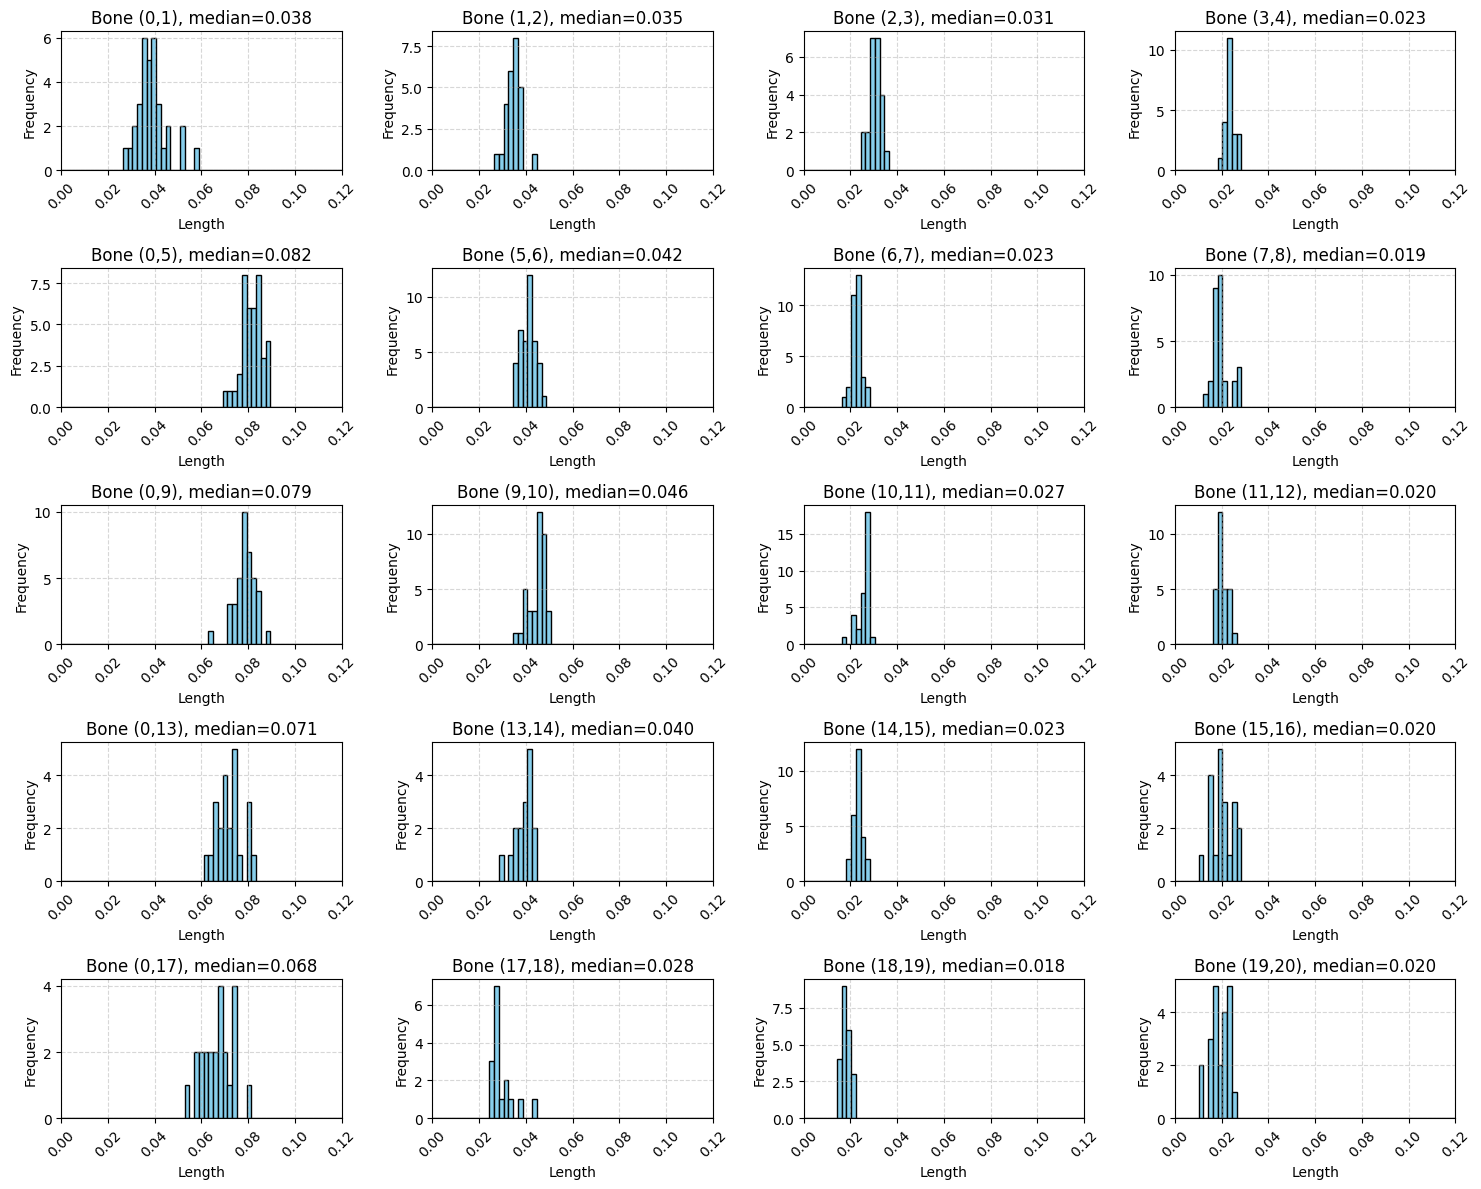

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Compute bone lengths for all gestures and both hands
num_bones = len(connections)
all_bone_lengths_norm = []

for g_idx, gesture_dict in enumerate(results):
    # results_optimized[g_idx] is a dict: {0: left_hand, 1: right_hand}
    for hand_idx in [0, 1]:
        if hand_idx not in gesture_dict:
            continue
        gesture_xyz = gesture_dict[hand_idx]  # shape (21, 3)
        bone_lengths = np.full(num_bones, np.nan)
        for b_idx, (i, j) in enumerate(connections):
            if not (np.any(np.isnan(gesture_xyz[i])) or np.any(np.isnan(gesture_xyz[j]))):
                bone_lengths[b_idx] = np.linalg.norm(gesture_xyz[i] - gesture_xyz[j])
        all_bone_lengths_norm.append(bone_lengths)

all_bone_lengths_norm = np.vstack(all_bone_lengths_norm)  # shape (#samples, num_bones)

# Plot histograms
fig, axes = plt.subplots(nrows=5, ncols=4, figsize=(15, 12))
axes = axes.flatten()

# Define uniform bin edges
bin_edges = np.linspace(0.0, 0.12, 60)

for b_idx, (i, j) in enumerate(connections):
    lengths = all_bone_lengths_norm[:, b_idx]
    lengths = lengths[~np.isnan(lengths)]
    median_len = np.median(lengths) if len(lengths) > 0 else np.nan
    print(f"{i, j}: {median_len}")

    ax = axes[b_idx]
    ax.hist(lengths, bins=bin_edges, color='skyblue', edgecolor='black')
    ax.set_title(f"Bone ({i},{j}), median={median_len:.3f}")
    ax.set_xlabel("Length")
    ax.set_ylabel("Frequency")
    ax.set_xlim(0, 0.12)
    ax.xaxis.set_major_formatter(mticker.ScalarFormatter(useOffset=False))
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, linestyle='--', alpha=0.5)




# Hide unused subplots
for ax in axes[num_bones:]:
    ax.axis('off')

plt.tight_layout()
plt.show()



In [10]:
import torch
from pathlib import Path
import numpy as np

def optimize_hand_multicam_gpu(
    arr,
    intrinsics_dir,
    suffix,
    extrinsics_path,
    cams=['gopro5','gopro6','gopro7','gopro8','gopro9','gopro10','gopro11','gopro12'],
    frame_index=0,
    hand_index=0,
    max_iters=50,
    connections=None,
    median_bone_lengths=None,
    lambda_bone=10.0,
    clamp_val=5.0
):
    """
    Optimize 3D hand points using multi-camera 2D observations.

    Loss = reprojection error + lambda_bone * bone_length deviation

    Returns:
        xyz_init: optimized 3D points (numpy array of shape [num_joints, 3])
    """

    # --- Initial triangulation ---
    xyz_init_np, _ = triangulate_hand(arr, intrinsics_dir, suffix, extrinsics_path, cams, frame_index, hand_index)
    xyz_init = torch.tensor(xyz_init_np, dtype=torch.float32, device=device, requires_grad=True)
    xyz_init_orig = xyz_init.clone().detach()  # store original positions

    # --- Load extrinsics & intrinsics ---
    ext_all = load_aligned_extrinsics_json(extrinsics_path)
    P_by_cam, K_by_cam, dist_by_cam = {}, {}, {}
    for cam in cams:
        intr_path = Path(intrinsics_dir) / f"{cam}{suffix}_intrinsics.json"
        K, dist = load_intrinsics_json(str(intr_path))
        K_by_cam[cam] = torch.tensor(K, dtype=torch.float32, device=device)
        dist_by_cam[cam] = torch.tensor(dist, dtype=torch.float32, device=device)

        # build projection matrix from aligned extrinsics
        R_cw = torch.tensor(ext_all[f"blender2{cam}"]["R_cw"], dtype=torch.float32, device=device)
        t_cw = torch.tensor(ext_all[f"blender2{cam}"]["t_cw"], dtype=torch.float32, device=device).reshape(3,1)
        # R_wc = R_cw.transpose(-1, -2)
        # t_wc = -R_wc @ t_cw
        P_by_cam[cam] = K_by_cam[cam] @ torch.cat([R_cw, t_cw], dim=1)

    

    # --- Precompute initial losses for normalization ---
    def closure_reproj(xyz):
        """
        Compute total reprojection error across all cameras.
        Only includes keypoints that are visible (score > 0, nonzero position).
        Error per joint = L2 distance between projected and observed keypoints.
        """
        total_loss = torch.zeros(1, device=device, dtype=torch.float32)
        contributing_cams = 0

        for cam in cams:
            frames = arr[cam]
            inst = frames[frame_index][hand_index]

            # Load 2D keypoints & confidence scores
            keypoints_2d_np = np.asarray(inst.keypoints, dtype=np.float32).reshape(-1, 2)
            scores_np = np.asarray(inst.keypoint_scores, dtype=np.float32).reshape(-1)

            # --- Visibility mask ---
            visible_mask = (scores_np > 0.1) & np.any(keypoints_2d_np != 0.0, axis=1)
            if not np.any(visible_mask):
                continue

            keypoints_2d = torch.tensor(keypoints_2d_np, device=device)
            visible_mask = torch.tensor(visible_mask, dtype=torch.bool, device=device)

            # --- Camera parameters ---
            R_cw = torch.tensor(ext_all[f"blender2{cam}"]["R_cw"], device=device, dtype=torch.float32)
            t_cw = torch.tensor(ext_all[f"blender2{cam}"]["t_cw"], device=device, dtype=torch.float32)
            # R_wc = R_cw.transpose(-1, -2)
            # t_wc = -R_wc @ t_cw
            K = K_by_cam[cam]
            dist = dist_by_cam[cam]

            # --- Project 3D points into this camera ---
            pts_cam = (R_cw @ xyz.T + t_cw.unsqueeze(1)).T  # [N,3]
            # pts_cam = ((xyz - t_cw) @ R_cw)
            valid_depth = pts_cam[:, 2] > 1e-6
            valid_mask = visible_mask & valid_depth

            if not torch.any(valid_mask):
                continue

            try:
                pts_proj = project_points_camera(pts_cam, K, dist)
            except Exception as e:
                print(f"⚠️ Projection failed for {cam}: {e}")
                continue
            
            # Replace NaNs/Infs safely
            pts_proj = torch.nan_to_num(pts_proj, nan=0.0, posinf=0.0, neginf=0.0)

            # # Align lengths in case of small mismatch
            # n = min(pts_proj.shape[0], keypoints_2d.shape[0])
            # pts_proj = pts_proj[:n]
            # keypoints_2d = keypoints_2d[:n]
            # valid_mask = valid_mask[:n]

            # --- Your requested reprojection error ---
            per_point_error = torch.norm(
                pts_proj[valid_mask] - keypoints_2d[valid_mask],
                dim=1
            )

            # Accumulate total loss
            total_loss = total_loss + torch.nan_to_num(per_point_error, nan=0.0).sum()
            contributing_cams += 1

        if contributing_cams == 0:
            # No valid observations -> return safe zero (keeps graph intact)
            return xyz.sum() * 0.0

        return total_loss


    def closure_bone(xyz):
        total = torch.tensor(0.0, dtype=torch.float32, device=device)  # <- tensor
        if connections is None or median_bone_lengths is None:
            return total
        for b_idx, (i, j) in enumerate(connections):
            if i < xyz.shape[0] and j < xyz.shape[0]:
                pi, pj = xyz[i], xyz[j]
                if torch.isfinite(pi).all() and torch.isfinite(pj).all():
                    total = total + (torch.norm(pi - pj + 1e-8) - median_bone_lengths[b_idx]) ** 2
        return total


    initial_reproj = closure_reproj(xyz_init).item() + 1e-8
    initial_bone = closure_bone(xyz_init).item() + 1e-8

    # --- Main closure for optimizer ---
    def closure():
        optimizer.zero_grad()
        # normalized losses
        reproj_loss = closure_reproj(xyz_init) / initial_reproj / 10
        # print(initial_reproj, closure_reproj(xyz_init), reproj_loss)
        bone_loss = closure_bone(xyz_init) / initial_bone
        total_loss = reproj_loss + lambda_bone * bone_loss

        # prevent NaN
        if not torch.isfinite(total_loss):
            total_loss = torch.tensor(0.0, device=device, requires_grad=True)

        total_loss.backward()
        return total_loss

    # --- LBFGS optimizer ---
    optimizer = torch.optim.LBFGS([xyz_init], lr=0.05, max_iter=20, history_size=10, line_search_fn='strong_wolfe')
    outer_iters = max(1, max_iters // 20)

    for it in range(outer_iters):
        optimizer.step(closure)

        # Clamp and reset if limit reached
        with torch.no_grad():
            xyz_init.clamp_(-clamp_val, clamp_val)
            if (xyz_init == clamp_val).any() or (xyz_init == -clamp_val).any():
                print(f"⚠️ Clamp limit reached at iteration {it}, resetting to original points")
                xyz_init[:] = xyz_init_orig
    
    # --- Compute final reprojection error ---
    final_reproj = closure_reproj(xyz_init).item()
    print(f"📏 Final reprojection error: {final_reproj:.6f}")

    return xyz_init.detach().cpu().numpy()


In [11]:
# import torch
# from pathlib import Path

# def optimize_hand_multicam_gpu(
#     arr,
#     intrinsics_dir,
#     extrinsics_path,
#     cams=['gopro5','gopro6','gopro7','gopro8','gopro9','gopro10','gopro11','gopro12'],
#     frame_index=0,
#     hand_index=0,
#     lr=5e-3,
#     num_iters=50,
#     device='cuda'
# ):
#     """
#     Optimize 3D hand points using multi-camera 2D annotations from `arr`.
#     Minimizes the mean reprojection error across all cameras.
#     """

#     """
#     Safe Adam optimization for reprojection error.
#     Ignores unannotated joints and avoids in-place operations.
#     """

#     # --- Initial triangulation ---
#     xyz_init_np, _ = triangulate_hand(arr, intrinsics_dir, extrinsics_path, cams, frame_index, hand_index)
#     xyz_init = torch.tensor(xyz_init_np, dtype=torch.float32, device=device, requires_grad=True)

#     # Print initial depth stats (sanity)
#     try:
#         print("Initial Z min/max:", float(xyz_init_np[:,2].min()), float(xyz_init_np[:,2].max()))
#     except Exception:
#         pass

#     # --- Load camera params ---
#     ext_all = load_aligned_extrinsics_json(extrinsics_path)
#     K_by_cam, Rcw_by_cam, tcw_by_cam, dist_by_cam = {}, {}, {}, {}
#     for cam in cams:
#         intr_path = Path(intrinsics_dir) / f"{cam}_synced_intrinsics.json"
#         K, dist = load_intrinsics_json(str(intr_path))
#         K_by_cam[cam] = torch.tensor(K, dtype=torch.float32, device=device)
#         dist_by_cam[cam] = torch.tensor(dist, dtype=torch.float32, device=device)

#         R_cw = torch.tensor(ext_all[f"blender2{cam}"]["R_cw"], dtype=torch.float32, device=device)
#         t_cw = torch.tensor(ext_all[f"blender2{cam}"]["t_cw"], dtype=torch.float32, device=device).reshape(3, 1)
#         Rcw_by_cam[cam] = R_cw
#         tcw_by_cam[cam] = t_cw

#     # --- Extract annotations and build masks ---
#     uv_obs_by_cam, mask_by_cam = {}, {}
#     for cam in cams:
#         inst = arr[cam][frame_index][hand_index]
#         uv = torch.tensor(inst.keypoints[0], dtype=torch.float32, device=device)     # [J,2]
#         scores = torch.tensor(inst.keypoint_scores[0], dtype=torch.float32, device=device)
#         valid = (scores > 0) & (uv[:, 0] > 0) & (uv[:, 1] > 0)
#         uv_obs_by_cam[cam] = uv
#         mask_by_cam[cam] = valid

#     optimizer = torch.optim.Adam([xyz_init], lr=lr)

#     # Optional: enable anomaly detection while debugging (slower)
#     # torch.autograd.set_detect_anomaly(True)

#     for it in range(num_iters):
#         optimizer.zero_grad()
#         total_loss = 0.0
#         valid_cam_count = 0

#         for cam in cams:
#             mask = mask_by_cam[cam]
#             if mask.sum() == 0:
#                 continue

#             R_cw = Rcw_by_cam[cam]
#             t_cw = tcw_by_cam[cam]
#             K = K_by_cam[cam]
#             dist = dist_by_cam[cam]
#             uv_obs = uv_obs_by_cam[cam]

#             # world -> camera (out-of-place)
#             points_cam = (R_cw @ xyz_init.T + t_cw).T  # [J,3]

#             # --- Z safety (out-of-place) ---
#             Z = points_cam[:, 2]
#             Z_safe = torch.clamp(Z, min=1e-4)  # prevent div by zero
#             points_cam_safe = torch.stack([points_cam[:,0], points_cam[:,1], Z_safe], dim=-1)

#             # Diagnostic checks
#             if not torch.isfinite(points_cam_safe).all():
#                 # locate offending joint(s)
#                 nan_mask = ~torch.isfinite(points_cam_safe).all(dim=1)
#                 print(f"[Iter {it}] Non-finite points_cam_safe in cam {cam}, joints:", torch.where(nan_mask)[0].cpu().numpy())
#                 # skip this camera for this iteration to avoid NaN backward
#                 continue

#             # Project
#             uv_pred = project_points_camera(points_cam_safe, K, dist)

#             if not torch.isfinite(uv_pred).all():
#                 print(f"[Iter {it}] Non-finite uv_pred for cam {cam}")
#                 # skip camera
#                 continue

#             # Per-joint squared errors
#             per_joint_sq = ((uv_pred - uv_obs) ** 2).sum(dim=-1)  # [J]

#             # Filter: joint must be annotated AND per_joint_sq finite
#             finite_mask = torch.isfinite(per_joint_sq)
#             valid_mask = mask & finite_mask

#             valid_count = int(valid_mask.sum().item())
#             if valid_count == 0:
#                 # nothing to contribute from this camera
#                 continue

#             # Mean over valid joints only (safe)
#             loss_cam = per_joint_sq[valid_mask].mean()
#             if not torch.isfinite(loss_cam):
#                 print(f"[Iter {it}] loss_cam is not finite for cam {cam}; stats per_joint (min,max):",
#                       float(per_joint_sq.min().item()), float(per_joint_sq.max().item()))
#                 continue

#             total_loss = total_loss + loss_cam  # accumulate
#             valid_cam_count += 1

#         if valid_cam_count == 0:
#             print("⚠️ No valid camera contributions this iteration — aborting.")
#             break

#         total_loss = total_loss / valid_cam_count

#         # final check before backward
#         if not torch.isfinite(total_loss):
#             print(f"⚠️ Non-finite total_loss at iter {it}. Aborting optimization.")
#             break

#         # Backprop
#         total_loss.backward()

#         # Clip grads to prevent explosion
#         torch.nn.utils.clip_grad_norm_([xyz_init], max_norm=5.0)

#         # Step
#         optimizer.step()

#         # Optional: keep values in a safe range to prevent overflow on next iter
#         with torch.no_grad():
#             # clamp coordinate magnitudes (out-of-place update on data is allowed inside no_grad)
#             xyz_init.data = torch.clamp(xyz_init.data, min=-1e5, max=1e5)

#         # Simple progress print
#         if it % 10 == 0 or it == num_iters - 1:
#             print(f"[Iter {it:03d}] Reproj Loss = {float(total_loss):.6e} (cams used: {valid_cam_count})")

#     return xyz_init.detach().cpu().numpy()


In [12]:
# import torch
# from pathlib import Path
# import numpy as np

# def optimize_hand_multicam_gpu(
#     arr,
#     intrinsics_dir,
#     extrinsics_path,
#     cams=['gopro5','gopro6','gopro7','gopro8','gopro9','gopro10','gopro11','gopro12'],
#     frame_index=0,
#     hand_index=0,
#     bone_connections=None,
#     median_bone_lengths=None,
#     lambda_bone=1e0,
#     lr=5e-2,
#     num_iters=70,
#     device='cuda'
# ):
#     """
#     Optimize 3D hand points using multi-camera 2D annotations from `arr`.
#     Only optimizes joints observed in at least one camera.
#     Bone-length constraint propagates plausible positions to unobserved joints.
#     """
    
#     # --- Initial triangulation ---
#     xyz_init_np, _ = triangulate_hand(arr, intrinsics_dir, extrinsics_path, cams, frame_index, hand_index)
#     xyz_init_np = np.nan_to_num(xyz_init_np, nan=0.0)  # replace NaNs with 0
#     xyz_init = torch.tensor(xyz_init_np, dtype=torch.float32, device=device)

#     if median_bone_lengths is not None:
#         median_bone_lengths = torch.tensor(median_bone_lengths, dtype=torch.float32, device=device)
#     if bone_connections is not None:
#         bone_connections = torch.tensor(bone_connections, dtype=torch.long, device=device)
    
#     # Print initial depth stats
#     try:
#         print("Initial Z min/max:", float(xyz_init_np[:,2].min()), float(xyz_init_np[:,2].max()))
#     except Exception:
#         pass
    
#     # --- Load camera params ---
#     ext_all = load_aligned_extrinsics_json(extrinsics_path)
#     K_by_cam, Rcw_by_cam, tcw_by_cam, dist_by_cam = {}, {}, {}, {}
#     for cam in cams:
#         intr_path = Path(intrinsics_dir) / f"{cam}_synced_intrinsics.json"
#         K, dist = load_intrinsics_json(str(intr_path))
#         K_by_cam[cam] = torch.tensor(K, dtype=torch.float32, device=device)
#         dist_by_cam[cam] = torch.tensor(dist, dtype=torch.float32, device=device)
        
#         R_cw = torch.tensor(ext_all[f"blender2{cam}"]["R_cw"], dtype=torch.float32, device=device)
#         t_cw = torch.tensor(ext_all[f"blender2{cam}"]["t_cw"], dtype=torch.float32, device=device).reshape(3,1)
#         Rcw_by_cam[cam] = R_cw
#         tcw_by_cam[cam] = t_cw
    
#     # --- Extract per-camera annotations and masks ---
#     uv_obs_by_cam, mask_by_cam = {}, {}
#     for cam in cams:
#         inst = arr[cam][frame_index][hand_index]
#         uv = torch.tensor(inst.keypoints[0], dtype=torch.float32, device=device)     # [J,2]
#         scores = torch.tensor(inst.keypoint_scores[0], dtype=torch.float32, device=device)
#         valid = (scores > 0) & (uv[:,0] > 0) & (uv[:,1] > 0)
#         uv_obs_by_cam[cam] = uv
#         mask_by_cam[cam] = valid
    
#     # --- Determine which joints are observed in any camera ---
#     observed_mask = torch.zeros(xyz_init.shape[0], dtype=torch.bool, device=device)
#     for cam in cams:
#         observed_mask |= mask_by_cam[cam]
    
#     # --- Create optimizer only for observed joints ---
#     xyz_opt = xyz_init[observed_mask].clone().detach().requires_grad_(True)
#     optimizer = torch.optim.Adam([xyz_opt], lr=lr)
    
#     # --- Optimization loop ---
#     for it in range(num_iters):
#         optimizer.zero_grad()
#         total_loss = 0.0
#         reproj_loss = 0.0
#         valid_cam_count = 0
        
#         # Map optimized joints back to full array
#         xyz_full = xyz_init.clone()
#         xyz_full[observed_mask] = xyz_opt
        
#         # Reprojection loss
#         for cam in cams:
#             mask = mask_by_cam[cam]
#             if mask.sum() == 0:
#                 continue
            
#             uv_obs = uv_obs_by_cam[cam]
#             R_cw = Rcw_by_cam[cam]
#             t_cw = tcw_by_cam[cam]
#             K = K_by_cam[cam]
#             dist = dist_by_cam[cam]
            
#             xyz_visible = xyz_full[mask]
#             uv_visible = uv_obs[mask]
            
#             points_cam = (R_cw @ xyz_visible.T + t_cw).T
#             Z_safe = torch.clamp(points_cam[:,2], min=1e-4)
#             points_cam_safe = torch.stack([points_cam[:,0], points_cam[:,1], Z_safe], dim=-1)
            
#             uv_pred = project_points_camera(points_cam_safe, K, dist)
#             per_joint_sq = ((uv_pred - uv_visible)**2).sum(dim=-1)
#             loss_cam = per_joint_sq.mean()
            
#             reproj_loss += loss_cam
#             valid_cam_count += 1
        
#         if valid_cam_count > 0:
#             reproj_loss /= valid_cam_count
        
#         # --- Bone-length constraint ---
#         if bone_connections is not None and median_bone_lengths is not None:
#             diffs = xyz_full[bone_connections[:,0]] - xyz_full[bone_connections[:,1]]
#             lengths = torch.norm(diffs, dim=1)
#             bone_loss = ((lengths - median_bone_lengths.to(device))**2).mean()
#             total_loss = reproj_loss + lambda_bone * bone_loss
        
#         # --- Backprop and step ---
#         total_loss.backward()
#         torch.nn.utils.clip_grad_norm_([xyz_opt], max_norm=5.0)
#         optimizer.step()
        
#         # Keep coordinates in safe range
#         with torch.no_grad():
#             xyz_opt.data = torch.clamp(xyz_opt.data, min=-1e5, max=1e5)
        
#         # Progress print
#         if it % 10 == 0 or it == num_iters - 1:
#             print(f"[Iter {it:03d}] Total Loss: {float(total_loss):.3e}, Reproj Loss: {float(reproj_loss):.3e}, Bone Loss: {float(lambda_bone * bone_loss):.3e} (cams used: {valid_cam_count})")

#     num_views_per_joint = torch.zeros(xyz_init.shape[0], dtype=torch.int, device=device)
#     for cam in cams:
#         num_views_per_joint += mask_by_cam[cam].int()

#     xyz_full = xyz_init.clone()
#     xyz_full[observed_mask] = xyz_opt.detach()

#     # Now apply threshold for reliability
#     xyz_full[num_views_per_joint < 3] = float('nan')

#     return xyz_full.detach().cpu().numpy()


In [14]:
results_optimized = []

for scene in range(1, 3):
    
    # Load and downsample 2D annotations
    f1 = np.load(f"inputs/nathan/chb{scene}_nathan/hand_poses_2d_fixed.npz", allow_pickle=True)
    arr = f1["poses_2d"].item()
    for cam in cams:
        input_2d[cam] = arr[cam][::30]
    # Iterate over frames
    for i in range(10):
        frame_result = {}  # store both hands for this frame
        
        # Iterate over hands: 0 = left, 1 = right
        for hand_index in [0, 1]:
            optimized_xyz = optimize_hand_multicam_gpu(
                arr=input_2d,
                intrinsics_dir="camera_poses/chb/camera_intrinsics",
                suffix = '',
                extrinsics_path="camera_poses/chb/camera_extrinsics/aligned_poses.json",
                cams=cams,
                frame_index=i,
                hand_index=hand_index,
                max_iters=50,
                # optimizer_type="adam",  # "lbfgs" or "adam"
                connections=connections,
                median_bone_lengths=median_bone_lengths,
                lambda_bone=1e2
            )
            frame_result[hand_index] = optimized_xyz
        
        results_optimized.append(frame_result)
        print(f"Scene {scene} Frame {i} optimized 3D points:")
        print("Left hand:", frame_result[0])
        print("Right hand:", frame_result[1])


⚠️ Clamp limit reached at iteration 0, resetting to original points
⚠️ Clamp limit reached at iteration 1, resetting to original points
📏 Final reprojection error: 578.671509
⚠️ Clamp limit reached at iteration 0, resetting to original points
⚠️ Clamp limit reached at iteration 1, resetting to original points
📏 Final reprojection error: 435.533295
Scene 1 Frame 0 optimized 3D points:
Left hand: [[-0.27740553 -0.21409334  1.1884812 ]
 [-0.26834625 -0.23110059  1.2171487 ]
 [-0.24503587 -0.23826149  1.2428622 ]
 [-0.21755429 -0.2479659   1.2436355 ]
 [-0.1989931  -0.26113182  1.2333492 ]
 [-0.20366019 -0.20810035  1.2248077 ]
 [-0.1894005  -0.24845879  1.2270049 ]
 [-0.21038944 -0.2574819   1.2231098 ]
 [        nan         nan         nan]
 [-0.19974291 -0.2103634   1.2056485 ]
 [-0.18994801 -0.2552865   1.2059697 ]
 [-0.21621229 -0.2625987   1.2051401 ]
 [-0.23901913 -0.25494573  1.2038937 ]
 [        nan         nan         nan]
 [-0.19602616 -0.25852245  1.1884824 ]
 [-0.21646895 -0.

In [ ]:
# results_optimized[16][1][:] = np.nan
# np.savez(f"final_labeled_poses/chb/hand_poses_3d.npz", poses_3d=results_optimized, allow_pickle=True)
# Remove frame 180 of scene 2, due to high drifting in the reprojection errors.


In [93]:
results_optimized = np.load(f"final_labeled_poses/chb/hand_poses_3d.npz", allow_pickle=True)["poses_3d"]
# results_optimized[16][1][:] = np.nan

In [94]:
# Remove wrist and first thumb joint
import copy
results_optimized_wo_wrist = copy.deepcopy(results_optimized)

for frame in range(len(results_optimized)):
    for hand_idx in [0, 1]:
        # results_optimized_wo_wrist[frame][hand_idx][[0, 1, 2, 5, 12, 13, 15, 16, 17, 20]] = np.nan
        results_optimized_wo_wrist[frame][hand_idx][[1, 0]] = np.nan
        # results_optimized_wo_wrist[frame][hand_idx][[0, 1, 2, 12, 13, 15, 16]] = np.nan

In [95]:
# results_optimized_true = copy.deepcopy(results_optimized)
# np.savez(f"final_labeled_poses/cha/full_hand_poses_3d_lambda_bone_1e2_10_joints_removed.npz", poses_3d=results_optimized_wo_wrist, allow_pickle=True)
results_optimized = results_optimized_wo_wrist

In [96]:
import numpy as np
import torch

def clean_results_optimized_nans(results_optimized):
    """
    Replace NaNs in results_optimized with zeros (in-place safe copy).
    
    Args:
        results_optimized: list of dicts {0: xyz_left, 1: xyz_right}
                           where xyz_* are numpy or torch arrays
    Returns:
        Cleaned results_optimized (same structure)
    """
    cleaned = []
    for frame_data in results_optimized:
        new_frame = {}
        for hand_idx, xyz in frame_data.items():
            if isinstance(xyz, torch.Tensor):
                xyz = torch.nan_to_num(xyz, nan=0.0, posinf=0.0, neginf=0.0)
            else:
                xyz = np.nan_to_num(xyz, nan=0.0, posinf=0.0, neginf=0.0)
            new_frame[hand_idx] = xyz
        cleaned.append(new_frame)
    return cleaned

In [97]:
results_optimized_no_nan = clean_results_optimized_nans(results_optimized)

num_scenes = 2
for scene_num in range(1, num_scenes + 1):
    all_3d_concat = []
    for frame_data in results_optimized_no_nan[(scene_num-1)*10:scene_num*10]:
        left = frame_data[0]
        right = frame_data[1]

        # Convert to numpy if they're torch tensors
        if not isinstance(left, np.ndarray):
            left = left.cpu().numpy()
        if not isinstance(right, np.ndarray):
            right = right.cpu().numpy()

        # Concatenate along the joint axis → shape: (N_left + N_right, 3)
        concat = np.concatenate([left, right], axis=0)
        all_3d_concat.append(concat)
    

        

    all_3d_concat = np.stack(all_3d_concat)  # shape: (num_frames, total_joints, 3)
    np.savez(f"final_labeled_poses/chb/chb{scene_num}/hand_poses_3d.npz", poses_3d=all_3d_concat, allow_pickle=True)


(0, 1): nan
(1, 2): nan
(2, 3): 0.030605526641011238
(3, 4): 0.023135378025472164
(0, 5): nan
(5, 6): 0.0418745931237936
(6, 7): 0.022876962088048458
(7, 8): 0.01880570687353611
(0, 9): nan
(9, 10): 0.04601011611521244
(10, 11): 0.026457009837031364
(11, 12): 0.01986860204488039
(0, 13): nan
(13, 14): 0.04032732546329498
(14, 15): 0.023493347689509392
(15, 16): 0.02020714059472084
(0, 17): nan
(17, 18): 0.02821966540068388
(18, 19): 0.017711241729557514
(19, 20): 0.01975349150598049


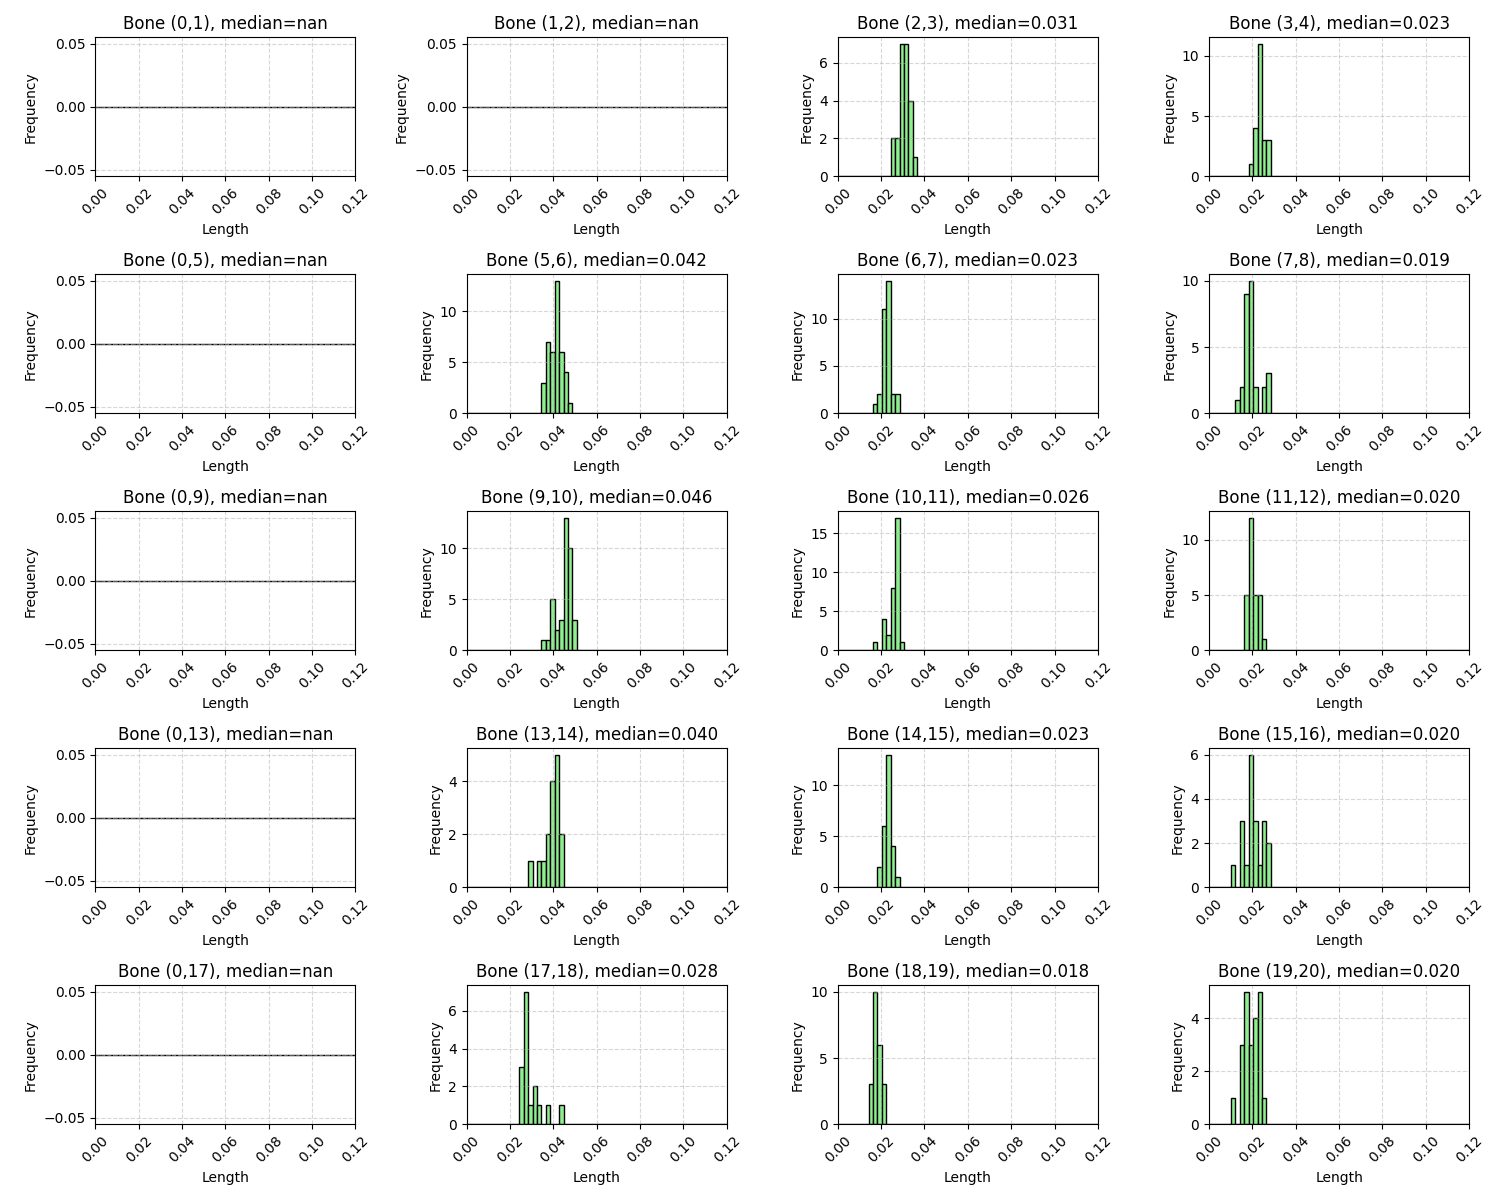

In [98]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Compute bone lengths for all gestures and both hands
num_bones = len(connections)
all_bone_lengths_norm = []

for g_idx, gesture_dict in enumerate(results_optimized):
    # results_optimized[g_idx] is a dict: {0: left_hand, 1: right_hand}
    for hand_idx in [0, 1]:
        if hand_idx not in gesture_dict:
            continue
        gesture_xyz = gesture_dict[hand_idx]  # shape (21, 3)
        bone_lengths = np.full(num_bones, np.nan)
        for b_idx, (i, j) in enumerate(connections):
            if not (np.any(np.isnan(gesture_xyz[i])) or np.any(np.isnan(gesture_xyz[j]))):
                bone_lengths[b_idx] = np.linalg.norm(gesture_xyz[i] - gesture_xyz[j])
        all_bone_lengths_norm.append(bone_lengths)

all_bone_lengths_norm = np.vstack(all_bone_lengths_norm)  # shape (#samples, num_bones)

# Plot histograms
fig, axes = plt.subplots(nrows=5, ncols=4, figsize=(15, 12))
axes = axes.flatten()

# Define uniform bin edges
bin_edges = np.linspace(0.0, 0.12, 60)

for b_idx, (i, j) in enumerate(connections):
    lengths = all_bone_lengths_norm[:, b_idx]
    lengths = lengths[~np.isnan(lengths)]
    median_len = np.median(lengths) if len(lengths) > 0 else np.nan
    print(f"{i, j}: {median_len}")

    ax = axes[b_idx]
    ax.hist(lengths, bins=bin_edges, color='lightgreen', edgecolor='black')
    ax.set_title(f"Bone ({i},{j}), median={median_len:.3f}")
    ax.set_xlabel("Length")
    ax.set_ylabel("Frequency")
    ax.set_xlim(0, 0.12)
    ax.xaxis.set_major_formatter(mticker.ScalarFormatter(useOffset=False))
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, linestyle='--', alpha=0.5)




# Hide unused subplots
for ax in axes[num_bones:]:
    ax.axis('off')

plt.tight_layout()
plt.show()



In [99]:
def visualize_all_cameras_optimized_vs_annotated(
    optimized_xyz_all,
    input_2d,
    video_paths,
    intrinsics_dir,
    suffix,
    extrinsics_path,
    cams,
    frame_index=0,
    point_radius=5,
):
    """
    Show 8 camera frames with both:
    - annotated 2D detections (circles, green/cyan) only where score == 1
    - optimized reprojections (x markers, red/darkblue) only where score == 1
    """

    # --- Load calibration ---
    ext_all = load_aligned_extrinsics_json(extrinsics_path)
    P_by_cam, K_by_cam, dist_by_cam = {}, {}, {}
    for cam in cams:
        intr_path = Path(intrinsics_dir) / f"{cam}{suffix}_intrinsics.json"
        K, dist = load_intrinsics_json(str(intr_path))
        K_by_cam[cam] = torch.tensor(K, dtype=torch.float32, device=device)
        dist_by_cam[cam] = torch.tensor(dist, dtype=torch.float32, device=device)

        # build projection matrix from aligned extrinsics
        R_cw = torch.tensor(ext_all[f"blender2{cam}"]["R_cw"], dtype=torch.float32, device=device)
        t_cw = torch.tensor(ext_all[f"blender2{cam}"]["t_cw"], dtype=torch.float32, device=device).reshape(3,1)
        P_by_cam[cam] = K_by_cam[cam] @ torch.cat([R_cw, t_cw], dim=1)

    


    # --- Colors ---
    colors_annot = {0: "lime", 1: "cyan"}     # circles = annotated (left, right)
    colors_opt   = {0: "red",  1: "darkblue"} # crosses = optimized (left, right)

    # --- Setup figure ---
    fig, axes = plt.subplots(4, 2, figsize=(12, 15))
    axes = axes.ravel()

    for cam_idx, cam in enumerate(cams):
        cap = cv2.VideoCapture(video_paths[cam])
        cap.set(cv2.CAP_PROP_POS_FRAMES, 30 * frame_index)  # assumes 30 fps
        ok, frame = cap.read()
        cap.release()
        if not ok:
            print(f"Could not read frame {frame_index} from {cam}")
            continue

        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        ax = axes[cam_idx]
        ax.imshow(frame)
        ax.set_title(cam)
        ax.axis("off")

        # -------------------
        # Annotated 2D points (original circles)
        # -------------------
        if cam in input_2d:
            frames = input_2d[cam]
            if frame_index < len(frames):
                for hand_index in [0, 1]:
                    if hand_index not in frames[frame_index]:
                        continue
                    inst = frames[frame_index][hand_index]
                    kpts = np.asarray(inst.keypoints, dtype=np.float64).reshape(-1, 2)
                    scores = np.asarray(inst.keypoint_scores, dtype=np.float64).reshape(-1)

                    mask = (scores >= 0.5)  # ✅ only full-confidence points
                    kpts_valid = kpts[mask]

                    ax.scatter(
                        kpts_valid[:, 0], kpts_valid[:, 1],
                        s=point_radius**2,
                        c=colors_annot[hand_index],
                        marker="o",
                        alpha=0.7
                    )

                    # -------------------
                    # Optimized 3D → 2D reprojection (X markers)
                    # -------------------
                    if hand_index in optimized_xyz_all:
                        xyz = optimized_xyz_all[hand_index]
                        if xyz is not None and len(xyz) > 0:
                            # Convert to torch tensor
                            xyz_torch = torch.tensor(xyz, dtype=torch.float32)

                            # Transform 3D points to camera coordinates using aligned extrinsics
                            R_cw = torch.tensor(ext_all[f"blender2{cam}"]["R_cw"], dtype=torch.float32)
                            t_cw = torch.tensor(ext_all[f"blender2{cam}"]["t_cw"], dtype=torch.float32).reshape(3,1)
                            
                            xyz_cam = (R_cw @ xyz_torch.T + t_cw).T  # shape (num_joints, 3)

                            # Project into 2D
                            pts_proj = project_points_camera(
                                xyz_cam, K_by_cam[cam], dist_by_cam[cam]
                            ).cpu().numpy()

                            # Only keep valid points
                            pts_proj_valid = pts_proj[mask & np.isfinite(pts_proj).all(axis=1)]

                            # Scatter plot
                            ax.scatter(
                                pts_proj_valid[:, 0], pts_proj_valid[:, 1],
                                s=point_radius**2,
                                c=colors_opt[hand_index],
                                marker="x",
                                alpha=0.9
                            )


    plt.tight_layout()
    plt.show()



In [100]:
%matplotlib widget
import ipywidgets as widgets
from IPython.display import display

#
ch = 'chb'

# --- Setup cameras and input data ---
cams = [f"gopro{i}" for i in range(5, 12)]
video_paths_template = f"inputs/{ch}/{ch}" + "{scene_num}/{cam}_synced_cut.MP4"
input_2d = {}

# Load all scenes into a dictionary to speed up switching
all_scenes_arr = {}
num_scenes = 2  # adjust based on your data

for scene_num in range(1, num_scenes + 1):
    f1 = np.load(f"inputs/nathan/{ch}{scene_num}_nathan/hand_poses_2d_fixed.npz", allow_pickle=True)
    arr = f1["poses_2d"].item()
    # Downsample frames (every 30th frame)
    arr_downsampled = {cam: arr[cam][::30] for cam in cams}
    all_scenes_arr[scene_num] = arr_downsampled

# --- Define interactive visualization function ---
def update_visualization(scene_slider, frame_slider):
    scene_num = scene_slider
    frame_idx = frame_slider
    arr = all_scenes_arr[scene_num]
    input_2d.clear()
    for cam in cams:
        input_2d[cam] = arr[cam]

    video_paths = {cam: video_paths_template.format(scene_num=scene_num, cam=cam) for cam in cams}

    visualize_all_cameras_optimized_vs_annotated(
        optimized_xyz_all=results_optimized[(scene_num-1)*10:scene_num*10][frame_idx],
        input_2d=input_2d,
        video_paths=video_paths,
        intrinsics_dir=f"camera_poses/{ch}/camera_intrinsics",
        suffix='',
        extrinsics_path=f"camera_poses/{ch}/camera_extrinsics/aligned_poses.json",
        cams=cams,
        frame_index=frame_idx
    )

# --- Create sliders ---
scene_slider = widgets.IntSlider(value=1, min=1, max=num_scenes, step=1, description="Scene")
frame_slider = widgets.IntSlider(value=0, min=0, max=9, step=1, description="Frame")

ui = widgets.HBox([scene_slider, frame_slider])
out = widgets.interactive_output(update_visualization, {'scene_slider': scene_slider, 'frame_slider': frame_slider})

display(ui, out)


Output()

In [101]:
def visualize_all_cameras_optimized_vs_annotated_vs_detected(
    optimized_xyz_all,
    detected_xyz,
    temporal_xyz,
    input_2d,
    video_paths,
    intrinsics_dir,
    extrinsics_path,
    cams,
    frame_index=0,
    point_radius=5,
):
    """
    Show 8 camera frames with both:
    - annotated 2D detections (circles, green/cyan) only where score == 1
    - optimized reprojections (x markers, red/darkblue) only where score == 1
    """

    # --- Load calibration ---
    ext_all = load_aligned_extrinsics_json(extrinsics_path)
    P_by_cam, K_by_cam, dist_by_cam = {}, {}, {}
    for cam in cams:
        intr_path = Path(intrinsics_dir) / f"{cam}_synced_intrinsics.json"
        K, dist = load_intrinsics_json(str(intr_path))
        K_by_cam[cam] = torch.tensor(K, dtype=torch.float32, device=device)
        dist_by_cam[cam] = torch.tensor(dist, dtype=torch.float32, device=device)

        # build projection matrix from aligned extrinsics
        R_cw = torch.tensor(ext_all[f"blender2{cam}"]["R_cw"], dtype=torch.float32, device=device)
        t_cw = torch.tensor(ext_all[f"blender2{cam}"]["t_cw"], dtype=torch.float32, device=device).reshape(3,1)
        P_by_cam[cam] = K_by_cam[cam] @ torch.cat([R_cw, t_cw], dim=1)

    


    # --- Colors ---
    colors_annot = {0: "lime", 1: "lime"}     # circles = annotated (left, right)
    colors_opt   = {0: "red",  1: "red"} # crosses = optimized (left, right)
    colors_det   = {0: "orange",  1: "orange"} # crosses = optimized (left, right)
    colors_temp   = {0: "fuchsia",  1: "fuchsia"} # crosses = optimized (left, right)

    # --- Setup figure ---
    fig, axes = plt.subplots(4, 2, figsize=(12, 15))
    axes = axes.ravel()

    for cam_idx, cam in enumerate(cams):
        cap = cv2.VideoCapture(video_paths[cam])
        cap.set(cv2.CAP_PROP_POS_FRAMES, 30 * frame_index)  # assumes 30 fps
        ok, frame = cap.read()
        cap.release()
        if not ok:
            print(f"Could not read frame {frame_index} from {cam}")
            continue

        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        ax = axes[cam_idx]
        ax.imshow(frame)
        ax.set_title(cam)
        ax.axis("off")

        # -------------------
        # Annotated 2D points (original circles)
        # -------------------
        if cam in input_2d:
            frames = input_2d[cam]
            if frame_index < len(frames):
                for hand_index in [0, 1]:
                    if hand_index not in frames[frame_index]:
                        continue
                    inst = frames[frame_index][hand_index]
                    kpts = np.asarray(inst.keypoints, dtype=np.float64).reshape(-1, 2)
                    scores = np.asarray(inst.keypoint_scores, dtype=np.float64).reshape(-1)

                    mask = (scores >= 0.5)  # ✅ only full-confidence points
                    kpts_valid = kpts[mask]

                    ax.scatter(
                        kpts_valid[:, 0], kpts_valid[:, 1],
                        s=point_radius**2,
                        c=colors_annot[hand_index],
                        marker="o",
                        alpha=0.7
                    )

                    # -------------------
                    # Optimized 3D → 2D reprojection (X markers)
                    # -------------------
                    if hand_index in optimized_xyz_all:
                        xyz = optimized_xyz_all[hand_index]
                        if xyz is not None and len(xyz) > 0:
                            # Convert to torch tensor
                            xyz_torch = torch.tensor(xyz, dtype=torch.float32)

                            # Transform 3D points to camera coordinates using aligned extrinsics
                            R_cw = torch.tensor(ext_all[f"blender2{cam}"]["R_cw"], dtype=torch.float32)
                            t_cw = torch.tensor(ext_all[f"blender2{cam}"]["t_cw"], dtype=torch.float32).reshape(3,1)
                            
                            xyz_cam = (R_cw @ xyz_torch.T + t_cw).T  # shape (num_joints, 3)

                            # Project into 2D
                            pts_proj = project_points_camera(
                                xyz_cam, K_by_cam[cam], dist_by_cam[cam]
                            ).cpu().numpy()

                            # Only keep valid points
                            pts_proj_valid = pts_proj[mask & np.isfinite(pts_proj).all(axis=1)]

                            # Scatter plot
                            ax.scatter(
                                pts_proj_valid[:, 0], pts_proj_valid[:, 1],
                                s=point_radius**2,
                                c=colors_opt[hand_index],
                                marker="x",
                                alpha=0.9
                            )

                            # -------------------
                    # Optimized 3D → 2D reprojection (X markers)
                    # -------------------
                    if hand_index in optimized_xyz_all:
                        xyz = detected_xyz[hand_index]
                        if xyz is not None and len(xyz) > 0:
                            # Convert to torch tensor
                            xyz_torch = torch.tensor(xyz, dtype=torch.float32)

                            # Transform 3D points to camera coordinates using aligned extrinsics
                            R_cw = torch.tensor(ext_all[f"blender2{cam}"]["R_cw"], dtype=torch.float32)
                            t_cw = torch.tensor(ext_all[f"blender2{cam}"]["t_cw"], dtype=torch.float32).reshape(3,1)
                            
                            xyz_cam = (R_cw @ xyz_torch.T + t_cw).T  # shape (num_joints, 3)

                            # Project into 2D
                            pts_proj = project_points_camera(
                                xyz_cam, K_by_cam[cam], dist_by_cam[cam]
                            ).cpu().numpy()

                            # Only keep valid points
                            pts_proj_valid = pts_proj[mask & np.isfinite(pts_proj).all(axis=1)]

                            # Scatter plot
                            ax.scatter(
                                pts_proj_valid[:, 0], pts_proj_valid[:, 1],
                                s=point_radius**2,
                                c=colors_det[hand_index],
                                marker="+",
                                alpha=0.9
                            )

                    # Optimized 3D → 2D reprojection (X markers)
                    # -------------------
                    if hand_index in optimized_xyz_all:
                        xyz = temporal_xyz[hand_index]
                        if xyz is not None and len(xyz) > 0:
                            # Convert to torch tensor
                            xyz_torch = torch.tensor(xyz, dtype=torch.float32)

                            # Transform 3D points to camera coordinates using aligned extrinsics
                            R_cw = torch.tensor(ext_all[f"blender2{cam}"]["R_cw"], dtype=torch.float32)
                            t_cw = torch.tensor(ext_all[f"blender2{cam}"]["t_cw"], dtype=torch.float32).reshape(3,1)
                            
                            xyz_cam = (R_cw @ xyz_torch.T + t_cw).T  # shape (num_joints, 3)

                            # Project into 2D
                            pts_proj = project_points_camera(
                                xyz_cam, K_by_cam[cam], dist_by_cam[cam]
                            ).cpu().numpy()

                            # Only keep valid points
                            pts_proj_valid = pts_proj[mask & np.isfinite(pts_proj).all(axis=1)]

                            # Scatter plot
                            ax.scatter(
                                pts_proj_valid[:, 0], pts_proj_valid[:, 1],
                                s=point_radius**2,
                                c=colors_temp[hand_index],
                                marker="+",
                                alpha=0.9
                            )


    plt.tight_layout()
    plt.show()



In [102]:
# %matplotlib widget
# import ipywidgets as widgets
# from IPython.display import display

# # --- Setup cameras and input data ---
# cams = [f"gopro{i}" for i in range(5, 13)]
# video_paths_template = "inputs/cha/cha{scene_num}/{cam}_synced_cut.MP4"
# input_2d = {}

# # Load all scenes into a dictionary to speed up switching
# all_scenes_arr = {}
# num_scenes = 2  # adjust based on your data
# detected_xyz = []
# temporal_xyz = []
# for scene_num in range(1, num_scenes + 1):
#     f1 = np.load(f"inputs/nathan/chb{scene_num}_nathan/hand_poses_2d_fixed.npz", allow_pickle=True)
#     arr = f1["poses_2d"].item()
#     # Downsample frames (every 30th frame)
#     arr_downsampled = {cam: arr[cam][::30] for cam in cams}
#     all_scenes_arr[scene_num] = arr_downsampled
    


# # --- Define interactive visualization function ---
# def update_visualization(scene_slider, frame_slider):
#     scene_num = scene_slider
#     frame_idx = frame_slider
#     arr = all_scenes_arr[scene_num]
#     input_2d.clear()
#     for cam in cams:
#         input_2d[cam] = arr[cam]
#     detected_xyz.clear()
#     f2 = np.load(f"output_3d/chb/anna{scene_num}/hand_poses_3d_temp_mapped.npz", allow_pickle=True)["poses_3d"]
#     detected_xyz_combined = f2[::30]
#     for gesture in detected_xyz_combined:
#         detected_xyz.append(
#             {
#                 0: gesture[:21],
#                 1: gesture[21:]
#             }
#         )
#     temporal_xyz.clear()
#     f3 = np.load(f"output_3d/cha/cha{scene_num}/hand_poses_3d_temp_mapped.npz", allow_pickle=True)["poses_3d"]
#     temporal_xyz_combined = f3[::30]
#     for gesture in temporal_xyz_combined:
#         temporal_xyz.append(
#             {
#                 0: gesture[:21],
#                 1: gesture[21:]
#             }
#         )

#     video_paths = {cam: video_paths_template.format(scene_num=scene_num, cam=cam) for cam in cams}

#     visualize_all_cameras_optimized_vs_annotated_vs_detected(
#         optimized_xyz_all=results_optimized[(scene_num-1)*10:scene_num*10][frame_idx],
#         detected_xyz=detected_xyz[frame_idx],
#         temporal_xyz = temporal_xyz[frame_idx],
#         input_2d=input_2d,
#         video_paths=video_paths,
#         intrinsics_dir="camera_poses/cha/camera_intrinsics",
#         extrinsics_path="camera_poses/cha/camera_extrinsics/aligned_poses.json",
#         cams=cams,
#         frame_index=frame_idx
#     )

# # --- Create sliders ---
# scene_slider = widgets.IntSlider(value=1, min=1, max=num_scenes, step=1, description="Scene")
# frame_slider = widgets.IntSlider(value=0, min=0, max=9, step=1, description="Frame")

# ui = widgets.HBox([scene_slider, frame_slider])
# out = widgets.interactive_output(update_visualization, {'scene_slider': scene_slider, 'frame_slider': frame_slider})

# display(ui, out)


In [103]:
%matplotlib widget
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider
import numpy as np

def interactive_hand_view(results_original, results_optimized, connections_one_hand):
    """
    Interactive 3D viewer for two-hand gestures (42 joints).
    
    results_original: list of dicts {0: left_hand_xyz, 1: right_hand_xyz}
    results_optimized: list of dicts {0: left_hand_xyz, 1: right_hand_xyz}
    connections_one_hand: list of bone tuples for one hand (21 joints)
    """
    num_frames = len(results_original)

    # ----- Build connections for both hands -----
    connections = []
    connections.extend(connections_one_hand)  # left hand
    connections.extend([(i + 21, j + 21) for (i, j) in connections_one_hand])  # right hand

    # ----- Custom Colors -----
    def make_gradient(base_rgb, n):
        """Return a list of n colors from dark to light based on base_rgb (0-1 range)."""
        factors = np.linspace(0.4, 1.0, n)  # darker at base, lighter at tip
        return [(base_rgb[0]*f, base_rgb[1]*f, base_rgb[2]*f) for f in factors]

    # Wrist
    colors_left = [(0, 0, 0)]  

    # Thumb = red
    colors_left += make_gradient((1, 0, 0), 4)
    # Index = green
    colors_left += make_gradient((0, 1, 0), 4)
    # Middle = blue
    colors_left += make_gradient((0, 0, 1), 4)
    # Ring = orange
    colors_left += make_gradient((1, 0.5, 0), 4)
    # Pinky = violet
    colors_left += make_gradient((0.6, 0, 0.8), 4)

    # Right hand uses same colors
    joint_colors = colors_left + colors_left  

    def plot_frame(frame_idx=0, elev=30, azim=45, roll=0):
        # Stack both hands into a (42,3) array
        xyz_orig = np.vstack([results_original[frame_idx][0],
                              results_original[frame_idx][1]])
        xyz_opt = np.vstack([results_optimized[frame_idx][0],
                             results_optimized[frame_idx][1]])

        fig = plt.figure(figsize=(14, 6))
        ax1 = fig.add_subplot(121, projection='3d')
        ax2 = fig.add_subplot(122, projection='3d')

        # Scatter plots for joints
        ax1.scatter(xyz_orig[:, 0], xyz_orig[:, 1], xyz_orig[:, 2], c=joint_colors, s=50)
        ax2.scatter(xyz_opt[:, 0], xyz_opt[:, 1], xyz_opt[:, 2], c=joint_colors, s=50)

        # Draw bones (use color of base joint)
        for i, j in connections:
            if not (np.any(np.isnan(xyz_orig[i])) or np.any(np.isnan(xyz_orig[j]))):
                ax1.plot([xyz_orig[i, 0], xyz_orig[j, 0]],
                         [xyz_orig[i, 1], xyz_orig[j, 1]],
                         [xyz_orig[i, 2], xyz_orig[j, 2]], c=joint_colors[i])
            if not (np.any(np.isnan(xyz_opt[i])) or np.any(np.isnan(xyz_opt[j]))):
                ax2.plot([xyz_opt[i, 0], xyz_opt[j, 0]],
                         [xyz_opt[i, 1], xyz_opt[j, 1]],
                         [xyz_opt[i, 2], xyz_opt[j, 2]], c=joint_colors[i])

        # Titles
        ax1.set_title("Original Hands")
        ax2.set_title("Optimized Hands")

        # Sync camera views
        try:
            ax1.view_init(elev=elev, azim=azim, roll=roll)
            ax2.view_init(elev=elev, azim=azim, roll=roll)
        except TypeError:  # older matplotlib without roll
            ax1.view_init(elev=elev, azim=azim)
            ax2.view_init(elev=elev, azim=azim)

        plt.show()

    # Interactive sliders
    interact(plot_frame,
             frame_idx=IntSlider(min=0, max=num_frames - 1, step=1, value=0, description='Frame'),
             elev=IntSlider(min=-90, max=90, step=5, value=-40, description='Elevation'),
             azim=IntSlider(min=-180, max=180, step=5, value=-70, description='Azimuth'),
             roll=IntSlider(min=-180, max=180, step=5, value=150, description='Roll'))

# Example usage:
connections_one_hand = [
    (0,1),(1,2),(2,3),(3,4),      # Thumb
    (0,5),(5,6),(6,7),(7,8),      # Index
    (0,9),(9,10),(10,11),(11,12), # Middle
    (0,13),(13,14),(14,15),(15,16), # Ring
    (0,17),(17,18),(18,19),(19,20)  # Pinky
]

interactive_hand_view(results, results_optimized, connections_one_hand)


interactive(children=(IntSlider(value=0, description='Frame', max=19), IntSlider(value=-40, description='Eleva…

In [104]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def compute_reprojection_error(
    results_optimized,
    arr,
    intrinsics_dir,
    extrinsics_path,
    cams,
    frame_index=0,
    keypoint_score_threshold=0.5,
    apply_distortion=True,
    plot_type="violin"
):
    """
    Computes reprojection error per camera for both hands in one frame.

    Args:
        results_optimized: dict {0: left_hand_xyz, 1: right_hand_xyz}
        arr: dict with 2D annotations per camera
        intrinsics_dir: path to camera intrinsics
        extrinsics_path: path to camera extrinsics
        cams: list of camera names
        frame_index: which frame to use
        keypoint_score_threshold: ignore low-confidence keypoints
        apply_distortion: whether to apply distortion
        plot_type: 'violin' or 'box'

    Returns:
        errors_per_cam: dict of camera → np.array of reprojection errors (px)
        mean_errors: dict of camera → mean reprojection error
    """
    # --- Load calibration data ---
    ext_all = load_aligned_extrinsics_json(extrinsics_path)
    P_by_cam, K_by_cam, dist_by_cam = {}, {}, {}
    for cam in cams:
        intr_path = Path(intrinsics_dir) / f"{cam}_synced_intrinsics.json"
        K, dist = load_intrinsics_json(str(intr_path))
        K_by_cam[cam] = torch.tensor(K, dtype=torch.float32, device=device)
        dist_by_cam[cam] = torch.tensor(dist, dtype=torch.float32, device=device)

        # build projection matrix from aligned extrinsics
        R_cw = torch.tensor(ext_all[f"blender2{cam}"]["R_cw"], dtype=torch.float32, device=device)
        t_cw = torch.tensor(ext_all[f"blender2{cam}"]["t_cw"], dtype=torch.float32, device=device).reshape(3,1)
        P_by_cam[cam] = K_by_cam[cam] @ torch.cat([R_cw, t_cw], dim=1)

    # --- Torch setup ---
    errors_per_cam = {}
    mean_errors = {}

    # --- Process each camera ---
    for cam in cams:
        frames = arr[cam]
        total_errors = []

        for hand_index in [0, 1]:
            if hand_index not in results_optimized:
                continue
            xyz_3d = results_optimized[hand_index]
            if np.all(np.isnan(xyz_3d)):
                continue

            xyz_torch = torch.tensor(xyz_3d, dtype=torch.float32)

            inst = frames[frame_index][hand_index]
            kpts_2d = np.asarray(inst["keypoints"], dtype=np.float32).reshape(-1, 2)
            scores = np.asarray(inst["keypoint_scores"], dtype=np.float32).reshape(-1)
            mask = scores >= keypoint_score_threshold

            if np.sum(mask) == 0:
                continue

            # Project 3D → 2D
            R_cw = torch.tensor(ext_all[f"blender2{cam}"]["R_cw"], dtype=torch.float32, device=device)
            t_cw = torch.tensor(ext_all[f"blender2{cam}"]["t_cw"], dtype=torch.float32, device=device).reshape(3,1)
            K = K_by_cam[cam]
            dist = dist_by_cam[cam] if apply_distortion else None

            pts_cam = (R_cw @ xyz_torch.T + t_cw[:, None]).T
            proj_2d = project_points_camera(pts_cam, K, dist, apply_distortion).cpu().numpy()

            diffs = proj_2d[mask] - kpts_2d[mask]
            valid = ~np.isnan(diffs).any(axis=1)
            diffs = diffs[valid]

            if len(diffs) > 0:
                errors = np.linalg.norm(diffs, axis=1)
                total_errors.extend(errors.tolist())

        if len(total_errors) > 0:
            errors_per_cam[cam] = np.array(total_errors)
            mean_errors[cam] = np.mean(total_errors)
        else:
            errors_per_cam[cam] = np.array([])
            mean_errors[cam] = np.nan

    # --- Visualization ---
    valid_cams = [cam for cam in cams if len(errors_per_cam[cam]) > 0]
    if len(valid_cams) == 0:
        print("No valid points found for reprojection error computation.")
        return errors_per_cam, mean_errors

    plt.figure(figsize=(10, 5))
    data = [errors_per_cam[c] for c in valid_cams]

    if plot_type == "violin":
        plt.violinplot(data, showmeans=True, showmedians=True)
    else:
        plt.boxplot(data)

    plt.xticks(np.arange(1, len(valid_cams) + 1), valid_cams, rotation=45)
    plt.ylabel("Reprojection Error (pixels)")
    plt.title(f"Frame {frame_index} — Reprojection Error per Camera")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

    return errors_per_cam, mean_errors


In [105]:
import torch
import numpy as np

def compute_reprojection_error_single_cam(
    xyz_3d,                # (21, 3) numpy array, optimized 3D joints in world coordinates
    cam_name,              # e.g. "gopro6"
    frame_index,           # frame index
    hand_index,            # 0=left, 1=right
    intrinsics_dir,        # path to intrinsics folder
    extrinsics_path,       # path to extrinsics JSON
    score_thresh=0.1,      # ignore joints below this confidence
    apply_distortion=True # whether to apply distortion
):
    """
    Computes per-joint 2D reprojection error for one camera, one frame, one hand.
    Returns:
        reproj_errors: list of per-joint errors in pixels (NaN if joint not visible)
        valid_mask: boolean mask for joints used
        mean_error: mean reprojection error across visible joints
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # --- Load camera parameters ---
    K, dist = load_intrinsics_json(f"{intrinsics_dir}/{cam_name}_synced_intrinsics.json")
    ext_all = load_aligned_extrinsics_json(extrinsics_path)
    R_cw = ext_all[f"blender2{cam_name}"]["R_cw"]
    t_cw = ext_all[f"blender2{cam_name}"]["t_cw"]

    # --- 2D keypoints and visibility ---
    scene = frame_index//10
    idx = frame_index%10
    f1 = np.load(f"inputs/nathan/cha{scene+1}_nathan/hand_poses_2d_fixed.npz", allow_pickle=True)
    arr = f1["poses_2d"].item()
    for cam in cams:
        input_2d[cam] = arr[cam][::30]
    inst = input_2d[cam_name][idx][hand_index]
    kpts_2d = np.asarray(inst["keypoints"], dtype=np.float32).reshape(-1, 2)
    scores = np.asarray(inst["keypoint_scores"], dtype=np.float32).reshape(-1)
    valid_mask = scores >= score_thresh
    if valid_mask.sum() == 0:
        print(f"No visible joints for {cam_name}, frame {frame_index}, hand {hand_index}")
        return None, None, None

    # --- Convert to torch ---
    xyz_torch = torch.tensor(xyz_3d, dtype=torch.float32, device=device)
    R_cw_t = torch.tensor(R_cw, dtype=torch.float32, device=device)
    t_cw_t = torch.tensor(t_cw, dtype=torch.float32, device=device)
    K_t = torch.tensor(K, dtype=torch.float32, device=device)
    dist_t = torch.tensor(dist, dtype=torch.float32, device=device)

    # --- Project to 2D ---
    pts_cam = (R_cw_t @ xyz_torch.T + t_cw_t[:, None]).T
    proj_2d = project_points_camera(pts_cam, K_t, dist_t, apply_distortion)
    proj_2d = proj_2d.detach().cpu().numpy()

    # --- Compute per-joint reprojection error ---
    diffs = np.linalg.norm(proj_2d[valid_mask] - kpts_2d[valid_mask], axis=1)
    reproj_errors = np.full(kpts_2d.shape[0], np.nan)
    reproj_errors[valid_mask] = diffs
    mean_error = np.nanmean(reproj_errors)

    return reproj_errors, valid_mask, mean_error


In [106]:
import numpy as np

def compute_reprojection_errors_all_cams_frames(
    results_optimized,   # list of dicts: {0: left_hand_xyz, 1: right_hand_xyz}
    cams,                # list of camera names
    hand_index=0,        # 0=left, 1=right
    intrinsics_dir="", 
    extrinsics_path="", 
    score_thresh=0.1,
    apply_distortion=True
):
    """
    Computes per-joint reprojection errors for all frames and cameras.
    Returns:
        errors_stacked: numpy array of shape (num_cams*num_frames, num_joints)
                        NaN where joint was not visible in that camera/frame
    """
    num_frames = len(results_optimized)
    num_joints = results_optimized[0][hand_index].shape[0]

    errors_list = []

    for frame_idx in range(num_frames):
        xyz_3d = results_optimized[frame_idx][hand_index]

        for cam_name in cams:
            reproj_errors, valid_mask, mean_err = compute_reprojection_error_single_cam(
                xyz_3d=xyz_3d,
                cam_name=cam_name,
                frame_index=frame_idx,
                hand_index=hand_index,
                intrinsics_dir=intrinsics_dir,
                extrinsics_path=extrinsics_path,
                score_thresh=score_thresh,
                apply_distortion=apply_distortion
            )

            if reproj_errors is not None:
                errors_list.append(reproj_errors)
            else:
                # If no visible joints, append NaNs
                errors_list.append(np.full(num_joints, np.nan))

    errors_stacked = np.vstack(errors_list)  # shape: (num_cams*num_frames, num_joints)
    return errors_stacked


In [107]:
# cams = ['gopro5','gopro6','gopro7','gopro8','gopro9','gopro10','gopro11']
# hand_index = 0  # left han
# errors_left = compute_reprojection_errors_all_cams_frames(
#     results_optimized=results_optimized,
#     cams=cams,
#     hand_index=hand_index,
#     intrinsics_dir="camera_poses/cha/camera_intrinsics",
#     extrinsics_path="camera_poses/cha/camera_extrinsics/aligned_poses.json",
#     score_thresh=0.1
# )

# errors_right = compute_reprojection_errors_all_cams_frames(
#     results_optimized=results_optimized,
#     cams=cams,
#     hand_index=1,
#     intrinsics_dir="camera_poses/cha/camera_intrinsics",
#     extrinsics_path="camera_poses/cha/camera_extrinsics/aligned_poses.json",
#     score_thresh=0.1
# )

# errors_all = np.vstack([errors_left, errors_right])
# print("Stacked reprojection errors shape:", errors_all.shape)
# # Each column corresponds to one joint, each row is a camera/frame observation


In [108]:
# import matplotlib.pyplot as plt
# import numpy as npdef 

# def plot_violin_per_joint_numpy(errors_stacked):
#     """
#     Creates a violin plot per joint from stacked reprojection errors using numpy + matplotlib.
#     Displays the mean error above each violin.    errors_stacked: np.array of shape (num_observations, num_joints)
#     """
#     num_joints = errors_stacked.shape[1]
#     positions = np.arange(num_joints)    
#     mean_errors = np.zeros(num_joints)
#     median_errors = np.zeros(num_joints)
#     plt.figure(figsize=(15,6))    
#     for j in range(num_joints):
#         data = errors_stacked[:, j]
#         data = data[~np.isnan(data)]  # remove NaNs
#         if len(data) == 0:
#             mean_errors[j] = np.nan
#             continue
#         mean_errors[j] = np.mean(data)
#         median_errors[j] = np.median(data)
#         parts = plt.violinplot(data, positions=[j], widths=0.8, showmeans=False, showmedians=True)
#         for pc in parts['bodies']:
#             # pc.set_facecolor('#1f77b4')
#             pc.set_alpha(0.5)
#         parts['cmedians'].set_color('red')    # --- Place mean above each violin ---
#     y_max = np.nanmax(errors_stacked)
#     y_offset = -1.75  # 5% offset above the top
#     # plt.ylim(top=y_max)  # extend ylim to fit text
#     for j in range(num_joints):
#         if not np.isnan(mean_errors[j]):
#             plt.text(j, y_offset, f"{mean_errors[j]:.1f} / {median_errors[j]:.1f}",
#                      ha='center', va='bottom', fontsize=9, color='black', rotation=0)
#             plt.xticks(positions, [f"J{i}" for i in range(num_joints)], rotation=45)
#     plt.ylabel("Reprojection Error (px)")
#     plt.title("Per-Joint Reprojection Errors (All Cameras × Frames)")
#     plt.grid(axis='y', linestyle='--', alpha=0.5)
#     plt.tight_layout()
#     plt.show()# --- Example usage ---
# plot_violin_per_joint_numpy(errors_all)

In [109]:
# import pandas as pd
# import numpy as np
#  # 0:79, 560:639
#  # 80:159, 640:719
#  # 160:239, 720:799
#  # 240:319, 800:879
#  # 320:399, 880:959
#  # 400:479, 960:1039
#  # 480:559, 1040:1119
#  # Example: get a subset
# pd.set_option('display.max_columns', None)
# single_joint_errors = errors_all
# df = pd.DataFrame(single_joint_errors)
# subset = df
# # For each column, get the top 20 largest errors and their indices
# top_per_column = {}
# for col in subset.columns:
#     top_per_column[col] = (
#         subset[col]
#         .sort_values(ascending=False)
#         .head(5)
#         .reset_index()  # keep the original index
#         .rename(columns={"index": "Original Index", col: "Error"})
#     )
# # Display results
# for col, top_df in top_per_column.items():
#     print(f"\n=== Top 20 Largest Errors for Joint {col} ===")
#     print(top_df)


In [110]:
# %matplotlib widget
# import ipywidgets as widgets
# from IPython.display import display
# idx = 498
# num = (idx - 560) if idx >= 560 else idx
# scene = num//80+1
# camera = (num - (scene-1)*80)%8+5
# frame = (num - (scene-1)*80)//8
# print(f"Scene: {scene}, Camera: {camera}, Frame: {frame*30}, Hand: {'left' if idx < 560 else 'right'}")

# # --- Setup cameras and input data ---
# cams = [f"gopro{i}" for i in range(5, 13)]
# video_paths_template = "inputs/cha/cha{scene_num}/{cam}_synced_cut.MP4"
# input_2d = {}

# # Load all scenes into a dictionary to speed up switching
# all_scenes_arr = {}
# num_scenes = 7  # adjust based on your data

# for scene_num in range(1, num_scenes + 1):
#     f1 = np.load(f"inputs/nathan/cha{scene_num}_nathan_0/hand_poses_2d_fixed.npz", allow_pickle=True)
#     arr = f1["poses_2d"].item()
#     # Downsample frames (every 30th frame)
#     arr_downsampled = {cam: arr[cam][::30] for cam in cams}
#     all_scenes_arr[scene_num] = arr_downsampled

# # --- Define interactive visualization function ---
# def update_visualization(scene_slider, frame_slider):
#     scene_num = scene_slider
#     frame_idx = frame_slider
#     arr = all_scenes_arr[scene_num]
#     input_2d.clear()
#     for cam in cams:
#         input_2d[cam] = arr[cam]

#     video_paths = {cam: video_paths_template.format(scene_num=scene_num, cam=cam) for cam in cams}

#     visualize_all_cameras_optimized_vs_annotated(
#         optimized_xyz_all=results_optimized[(scene_num-1)*10:scene_num*10][frame_idx],
#         input_2d=input_2d,
#         video_paths=video_paths,
#         intrinsics_dir="camera_poses/cha/camera_intrinsics",
#         extrinsics_path="camera_poses/cha/camera_extrinsics/aligned_poses.json",
#         cams=cams,
#         frame_index=frame_idx
#     )

# # --- Create sliders ---
# scene_slider = widgets.IntSlider(value=scene, min=1, max=num_scenes, step=1, description="Scene")
# frame_slider = widgets.IntSlider(value=frame, min=0, max=9, step=1, description="Frame")

# ui = widgets.HBox([scene_slider, frame_slider])
# out = widgets.interactive_output(update_visualization, {'scene_slider': scene_slider, 'frame_slider': frame_slider})

# display(ui, out)


In [111]:
import torch
import numpy as np
from pathlib import Path
from mmengine.structures import InstanceData
from tqdm import tqdm

def reproject_all_to_instances(results_optimized, cams, intrinsics_dir, extrinsics_path):
    """
    Reproject optimized 3D hand joints into 2D image coordinates for all frames and cameras.

    Returns:
        dict: {
            'gopro5': [ {0: InstanceData, 1: InstanceData},  # frame 0
                        {0: InstanceData, 1: InstanceData},  # frame 1
                        ...
                      ],
            ...
        }
    """
    # --- Load calibration ---
    ext_all = load_aligned_extrinsics_json(extrinsics_path)
    K_by_cam, dist_by_cam, Rcw_by_cam, tcw_by_cam = {}, {}, {}, {}

    for cam in cams:
        intr_path = Path(intrinsics_dir) / f"{cam}_synced_intrinsics.json"
        K, dist = load_intrinsics_json(str(intr_path))

        K_by_cam[cam] = torch.tensor(K, dtype=torch.float32)
        dist_by_cam[cam] = torch.tensor(dist, dtype=torch.float32)
        Rcw_by_cam[cam] = torch.tensor(ext_all[f"blender2{cam}"]["R_cw"], dtype=torch.float32)
        tcw_by_cam[cam] = torch.tensor(ext_all[f"blender2{cam}"]["t_cw"], dtype=torch.float32)

    # --- Main reprojection loop ---
    reproj_data = {}

    for cam in tqdm(cams, desc="Reprojecting all cameras"):
        K = K_by_cam[cam]
        Rcw = Rcw_by_cam[cam]
        tcw = tcw_by_cam[cam]
        dist = dist_by_cam[cam]

        frames_list = []

        for frame_idx, frame_data in enumerate(results_optimized):
            frame_dict = {}

            for hand_index in [0, 1]:
                xyz_3d = torch.tensor(frame_data[hand_index], dtype=torch.float32)

                # Skip if no valid joints
                if torch.isnan(xyz_3d).all():
                    continue

                # Transform world → camera coordinates
                xyz_cam = (Rcw @ xyz_3d.T + tcw.view(3, 1)).T

                # Project into 2D pixels
                uv = project_points_camera(xyz_cam, K, dist_coeffs=dist, apply_distortion=False)

                # Compute validity mask
                valid_mask = ~torch.isnan(uv[:, 0])
                keypoint_scores = valid_mask.float().unsqueeze(0)

                # Fill missing points with zeros
                uv[~valid_mask] = 0.0

                # --- Create InstanceData container ---
                inst = InstanceData()
                inst.keypoints = uv.unsqueeze(0).cpu().numpy()  # (1, 21, 2)
                inst.keypoint_scores = keypoint_scores.cpu().numpy()
                inst.keypoints_visible = np.zeros_like(inst.keypoint_scores, dtype=np.float16)
                inst.bbox_scores = np.zeros((1,), dtype=np.float32)
                inst.bboxes = np.zeros((1, 4), dtype=np.int64)

                frame_dict[hand_index] = inst

            frames_list.append(frame_dict)

        reproj_data[cam] = frames_list

    return reproj_data


In [112]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def visualize_reprojected_from_video(video_path, reprojected_data, cam_name, frame_index, hand_index=0, connections_one_hand=None):
    """
    Visualize reprojected 2D keypoints for one frame from one camera, read directly from a video file.

    Args:
        video_path (str): Path to the camera video file (e.g. 'videos/gopro11.mp4').
        reprojected_data (dict): Output dictionary from your reprojection pipeline, e.g. {'gopro11': [ {0: InstanceData, 1: InstanceData}, ... ]}.
        cam_name (str): Camera name (key in reprojected_data), e.g. 'gopro11'.
        frame_index (int): Frame index to display.
        hand_index (int): 0 = left, 1 = right.
        connections_one_hand (list[tuple]): List of joint pairs to connect (for skeleton lines).
    """

    # --- Load the frame from video ---
    cap = cv2.VideoCapture(video_path)
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_index*30)
    ok, frame = cap.read()
    cap.release()

    if not ok or frame is None:
        print(f"⚠️ Could not read frame {frame_index} from {video_path}")
        return

    # Convert to RGB for plotting
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    # --- Extract keypoints from reprojection results ---
    try:
        inst = reprojected_data[cam_name][frame_index][hand_index]
    except KeyError:
        print(f"No hand {hand_index} found for frame {frame_index} in {cam_name}.")
        return

    keypoints = inst.keypoints[0]       # shape (21, 2)
    scores = inst.keypoint_scores[0]    # shape (21,)

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.imshow(frame)
    ax.set_title(f"{cam_name} | Frame {frame_index} | Hand: {'Left' if hand_index == 0 else 'Right'}")
    ax.axis("off")

    # Draw joints
    for j, (x, y) in enumerate(keypoints):
        if scores[j] > 0:
            ax.scatter(x, y, s=40, c='red' if hand_index == 0 else 'blue')

    # Draw bones
    if connections_one_hand is not None:
        for i, j in connections_one_hand:
            if scores[i] > 0 and scores[j] > 0:
                ax.plot([keypoints[i, 0], keypoints[j, 0]],
                        [keypoints[i, 1], keypoints[j, 1]],
                        c='lime' if hand_index == 0 else 'cyan', linewidth=2)

    plt.show()


In [113]:
from mmengine.structures import InstanceData

def build_reproj(results_optimized, input_2d, cams, intrinsics_dir, suffix, extrinsics_path, score_thresh=0.1):
    """
    Build a dictionary of reprojected points using InstanceData objects, compatible with input_2d.
    """
    import torch
    reproj_dict = {cam: [] for cam in cams}

    # --- Load calibration ---
    ext_all = load_aligned_extrinsics_json(extrinsics_path)
    K_by_cam, dist_by_cam, Rcw_by_cam, tcw_by_cam = {}, {}, {}, {}
    for cam in cams:
        intr_path = Path(intrinsics_dir) / f"{cam}{suffix}_intrinsics.json"
        K, dist = load_intrinsics_json(str(intr_path))
        K_by_cam[cam] = torch.tensor(K, dtype=torch.float32)
        dist_by_cam[cam] = torch.tensor(dist, dtype=torch.float32)
        Rcw_by_cam[cam] = torch.tensor(ext_all[f"blender2{cam}"]["R_cw"], dtype=torch.float32)
        tcw_by_cam[cam] = torch.tensor(ext_all[f"blender2{cam}"]["t_cw"], dtype=torch.float32)

    num_frames = len(results_optimized)
    for frame_idx in range(num_frames):
        frame_data = results_optimized[frame_idx]  # dict {0:left,1:right}

        for cam in cams:
            cam_frame = {}
            for hand_idx in [0, 1]:
                xyz_3d = frame_data[hand_idx]
                n_joints = xyz_3d.shape[0]

                # Keypoint scores from input_2d
                kp_scores = np.zeros((1, n_joints), dtype=np.float32)
                if cam in input_2d and frame_idx < len(input_2d[cam]):
                    annot = input_2d[cam][frame_idx][hand_idx]
                    kp_scores[0] = (annot.keypoint_scores[0] > score_thresh).astype(np.float32)

                # Only reproject visible points
                uv = np.zeros((1, n_joints, 2), dtype=np.float32)
                vis_mask = kp_scores[0] > 0
                if vis_mask.any():
                    xyz_cam = (Rcw_by_cam[cam] @ torch.tensor(xyz_3d.T, dtype=torch.float32) + tcw_by_cam[cam].unsqueeze(1)).T
                    uv_pts = project_points_camera(xyz_cam, K_by_cam[cam]).cpu().numpy()
                    uv[0, vis_mask] = uv_pts[vis_mask]

                # Create InstanceData
                inst = InstanceData()
                inst.keypoints = uv
                inst.keypoint_scores = kp_scores
                inst.keypoints_visible = kp_scores.astype(np.float16)
                inst.bbox_scores = np.zeros(1, dtype=np.float32)
                inst.bboxes = np.zeros((1,4), dtype=np.int64)

                cam_frame[hand_idx] = inst
            reproj_dict[cam].append(cam_frame)

    return reproj_dict


In [114]:
import numpy as np

def clean_reproj_dict_nans(reproj_dict):
    """
    Sets NaN or Inf values in reprojected points to 0,
    and sets the corresponding keypoint_scores to 0 as well.

    Args:
        reproj_dict: dict[cam][frame][hand_idx] = InstanceData with
                     .keypoints and .keypoint_scores

    Returns:
        Cleaned reproj_dict (in-place and returned)
    """
    for cam in reproj_dict:
        for frame_idx in range(len(reproj_dict[cam])):
            frame_data = reproj_dict[cam][frame_idx]
            for hand_idx, inst in frame_data.items():
                if not hasattr(inst, "keypoints") or not hasattr(inst, "keypoint_scores"):
                    continue

                kp = np.asarray(inst.keypoints)
                sc = np.asarray(inst.keypoint_scores)

                # mask NaN or Inf keypoints
                invalid_mask = ~np.isfinite(kp).all(axis=-1)
                if invalid_mask.any():
                    kp[invalid_mask] = 0.0
                    sc[invalid_mask] = 0.0
                    inst.keypoints = kp
                    inst.keypoint_scores = sc
    return reproj_dict


In [115]:
cams = [f"gopro{i}" for i in range(5, 12)]
scene_num = 2
ch = "chb"
for scene_num in range(1, num_scenes + 1):
    f1 = np.load(f"inputs/nathan/{ch}{scene_num}_nathan/hand_poses_2d_fixed.npz", allow_pickle=True)
    input_2d = f1["poses_2d"].item()
    # Downsample frames (every 30th frame)
    input_2d = {cam: input_2d[cam][::30] for cam in cams}
    print((scene_num-1)*10, scene_num*10)
    reproj_dict = build_reproj(
        results_optimized=results_optimized[(scene_num-1)*10:scene_num*10],
        input_2d=input_2d,  # same structure per frame/hand with keypoint_scores
        cams=cams,
        intrinsics_dir=f"camera_poses/{ch}/camera_intrinsics",
        suffix='',
        extrinsics_path=f"camera_poses/{ch}/camera_extrinsics/aligned_poses.json"
    )

    reproj_dict = clean_reproj_dict_nans(reproj_dict)

    
    np.savez(f"final_labeled_poses/{ch}/{ch}{scene_num}/hand_poses_2d_reprojected.npz", reproj_dict=reproj_dict, allow_pickle=True)

0 10
10 20


In [116]:
import copy
import numpy as np
from mmengine.structures import InstanceData

def insert_empty_frames_mmengine(reproj_dict, num_empty_between=29):
    """
    Inserts empty frames between each existing frame, keeping the InstanceData structure.
    
    reproj_dict: dict of {cam_name: list_of_frames}, where each frame is {hand_idx: InstanceData}
    num_empty_between: number of empty frames to insert between each frame
    """
    new_reproj = {}

    for cam, frames in reproj_dict.items():
        new_frames = []
        for i, frame in enumerate(frames):
            new_frames.append(frame)  # keep original frame

            if i == len(frames) - 1:
                continue

            # Insert empty frames
            for _ in range(num_empty_between):
                empty_frame = {}
                for hand_idx in frame:
                    inst = frame[hand_idx]
                    # Create empty InstanceData with same shape as original
                    empty_inst = InstanceData(
                        keypoints = np.zeros_like(inst.keypoints),
                        keypoint_scores = np.zeros_like(inst.keypoint_scores),
                        keypoints_visible = np.zeros_like(inst.keypoints_visible),
                        bboxes = np.zeros_like(inst.bboxes),
                        bbox_scores = np.zeros_like(inst.bbox_scores)
                    )
                    empty_frame[hand_idx] = empty_inst
                new_frames.append(empty_frame)
        
        new_reproj[cam] = new_frames

    return new_reproj

# Example usage:
reproj_dict_expanded = insert_empty_frames_mmengine(reproj_dict, num_empty_between=29)
print("Number of frames after expansion:", len(reproj_dict_expanded['gopro5']))


Number of frames after expansion: 271


In [117]:
num_scenes = 2  # adjust based on your data

for scene_num in range(1, num_scenes + 1):
    loaded = np.load(f"final_labeled_poses/chb/chb{scene_num}/hand_poses_2d_reprojected.npz", allow_pickle=True)
    reproj_dict = loaded["reproj_dict"].item()  # .item() to get the original dict
    reproj_dict_expanded = insert_empty_frames_mmengine(reproj_dict, num_empty_between=29)
    print("Number of frames after expansion:", len(reproj_dict_expanded['gopro5']))
    np.savez(f"final_labeled_poses/chb/chb{scene_num}/hand_poses_2d_reprojected_expanded.npz", reproj_dict=reproj_dict_expanded, allow_pickle=True)

Number of frames after expansion: 271
Number of frames after expansion: 271
